Generated availability matrix using SCIP tool. For different carbon budget, fetch the final best accuracy

# Display Test Accuracy

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [2]:
NON_IID, IID = "0.1", "100000"

In [13]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for batch_size in config.batch_sizes:
                    for seed in config.seeds:
                        for a in config.alphas:
                            for n_c in config.n_clients_list:
                                for av in config.availabilities:
                                    for part in config.participations:
                                        for biased in config.biased_list:

                                            event_dir = config.get_event_dir(batch_size, algorithm, lr, seed, 
                                                                                event, a, n_c, av, 
                                                                                config.n_rounds, part, biased, config.train_test) 

                                            print(av)
                                            if os.path.exists(event_dir):
                                                # print('x')
                                                # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                                _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                                _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                                _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                                _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                                ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                                max_accuracy = np.array(test_accuracy_values).max() * 100
                                                results.append({
                                                    "algorithm": algorithm, "availability": av,
                                                    "alpha": a, "participation": part,
                                                    "max_test_accuracy": float(max_accuracy),
                                                    "final_test_accuracy":test_accuracy_values[-1]*100,
                                                    "test_accuracy": np.array(test_accuracy_values),
                                                    "test_loss": "Test/Loss",
                                                    "train_accuracy": "Train/Metric",
                                                    "train_loss": "Train/Loss",
                                                    "seed": seed,
                                                    "lr": lr, "event": event, "n_clients": n_c,
                                                    "biased": biased
                                                })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [4]:
main_folder = 'model_quality'

In [5]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

def get_plt(tmp, data_type=NON_IID, ft=True):
    # Filter and process data for FedAvg
    fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
    fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Filter and process data for FedVarp
    fedvarp = tmp.loc[(tmp['algorithm'] == 'fedvarp') & (tmp['alpha'] == data_type)]
    fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Plot
    plt.figure(figsize=(10, 8))

    # Plot for FedAvg with lr differentiation
    for lr_value in fed_avg['lr'].unique():
        subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', label=f'FedAvg (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )

    # Plot for FedVarp with lr differentiation
    for lr_value in fedvarp['lr'].unique():
        subset = fedvarp[fedvarp['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', linestyle='--', label=f'FedVarp (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )
        

    # Add labels and legend
    plt.xlabel('Carbon Budget', fontsize=12)
    plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
    plt.title(f'{data_type} case {"with" if ft else "no"} ft', fontsize=14)
    plt.grid(visible=True, which='both')
    plt.minorticks_on()  # Enable minor ticks for finer granularity
    plt.ylim(0,1)
    plt.legend()
    plt.show()



In [6]:
_, test_accuracy_values = parse_tf_events_file("../logs/mnist_server/alphaF-0.5cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values1 = parse_tf_events_file("../logs/mnist_server/alphaF-0.6cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values2 = parse_tf_events_file("../logs/mnist_server/alphaF-0.68cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values3 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values4 = parse_tf_events_file("../logs/mnist_server/alphaF-0.72cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values5 = parse_tf_events_file("../logs/mnist_server/alphaF-0.75cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values6 = parse_tf_events_file("../logs/mnist_server/alphaF-0.8cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_valuesn = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-perfect/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_valuesn_ = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-1/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
plt.plot(test_accuracy_values,'b--', label='0.5')
plt.plot(test_accuracy_values1,'r--', label='0.6')
plt.plot(test_accuracy_values2,'g', label='0.68')
plt.plot(test_accuracy_values3,'r', label='0.7')
plt.plot(test_accuracy_values4,'k', label='0.72')
# plt.plot(test_accuracy_values5,'k', label='0.75')
plt.plot(test_accuracy_values6,'y', label='0.8')
plt.plot(test_accuracy_valuesn,'c', label='perfect')
plt.plot(test_accuracy_valuesn_,'m', label='not so perfect')
plt.legend()

2025-02-21 08:02:45.834605: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-21 08:02:49.883917: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-21 08:02:53.556846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-21 08:02:56.303910: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-21 08:02:57.064173: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-21 08:03:02.702262: I tensorflow/core/platform/cpu_feature_gu

DirectoryDeletedError: Directory ../logs/mnist_server/alphaF-0.5cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global has been permanently deleted

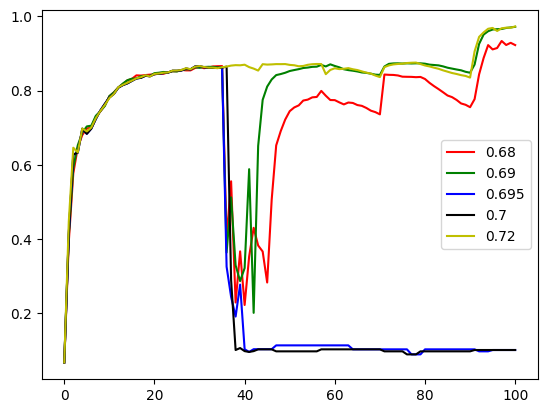

In [8]:
_, test_accuracy_values1 = parse_tf_events_file("../logs/mnist_server/alphaF-0.68cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values2 = parse_tf_events_file("../logs/mnist_server/alphaF-0.69cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values3 = parse_tf_events_file("../logs/mnist_server/alphaF-0.695cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values4 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values5 = parse_tf_events_file("../logs/mnist_server/alphaF-0.72cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")

plt.plot(test_accuracy_values1,'r', label='0.68')
plt.plot(test_accuracy_values2,'g', label='0.69')
plt.plot(test_accuracy_values3,'b', label='0.695')
plt.plot(test_accuracy_values4,'k', label='0.7')
plt.plot(test_accuracy_values5,'y', label='0.72')
plt.legend()


In [8]:
_, test_accuracy_values1 = parse_tf_events_file("../logs/mnist_server/alphaF-0.69cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values2 = parse_tf_events_file("../logs/mnist_server/alphaF-0.695cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values3 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values4 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")

_, test_accuracy_values5 = parse_tf_events_file("../logs/mnist_server/alphaF-0.69cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values6 = parse_tf_events_file("../logs/mnist_server/alphaF-0.695cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values7 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values8 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")

_, test_accuracy_values9 = parse_tf_events_file("../logs/mnist_server/alphaF-0.69cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values10 = parse_tf_events_file("../logs/mnist_server/alphaF-0.695cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values11 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values12 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")

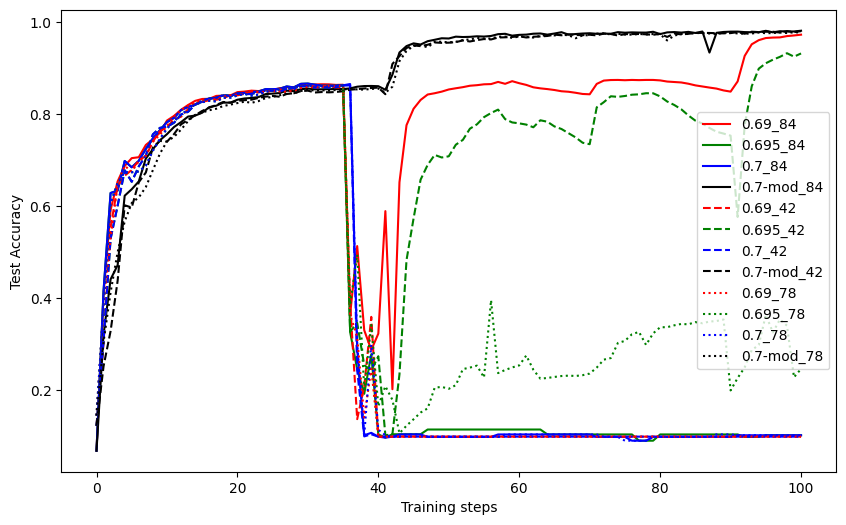

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(test_accuracy_values1,'r', label='0.69_84')
plt.plot(test_accuracy_values2,'g', label='0.695_84')
plt.plot(test_accuracy_values3,'b', label='0.7_84')
plt.plot(test_accuracy_values4,'k', label='0.7-mod_84')

plt.plot(test_accuracy_values5,'r',linestyle='dashed', label='0.69_42')
plt.plot(test_accuracy_values6,'g',linestyle='dashed', label='0.695_42')
plt.plot(test_accuracy_values7,'b',linestyle='dashed', label='0.7_42')
plt.plot(test_accuracy_values8,'k',linestyle='dashed', label='0.7-mod_42')

plt.plot(test_accuracy_values9,'r',linestyle='dotted', label='0.69_78')
plt.plot(test_accuracy_values10,'g',linestyle='dotted', label='0.695_78')
plt.plot(test_accuracy_values11,'b',linestyle='dotted', label='0.7_78')
plt.plot(test_accuracy_values12,'k',linestyle='dotted', label='0.7-mod_78')
plt.xlabel("Training steps")
plt.ylabel("Test Accuracy")
plt.legend()

In [10]:
_, test_accuracy_values1 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values2 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values3 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod-germ/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values4 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod-germ-less/biased_2/fedavg/alpha_0.1/lr_0.05/seed_84/train/global", tag="Test/Metric")

_, test_accuracy_values5 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values6 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values7 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod-germ/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values8 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod-germ-less/biased_2/fedavg/alpha_0.1/lr_0.05/seed_42/train/global", tag="Test/Metric")

_, test_accuracy_values9 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values10 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values11 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod-germ/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values12 = parse_tf_events_file("../logs/mnist_server/alphaF-0.7cb-10ft-mod-germ-less/biased_2/fedavg/alpha_0.1/lr_0.05/seed_78/train/global", tag="Test/Metric")

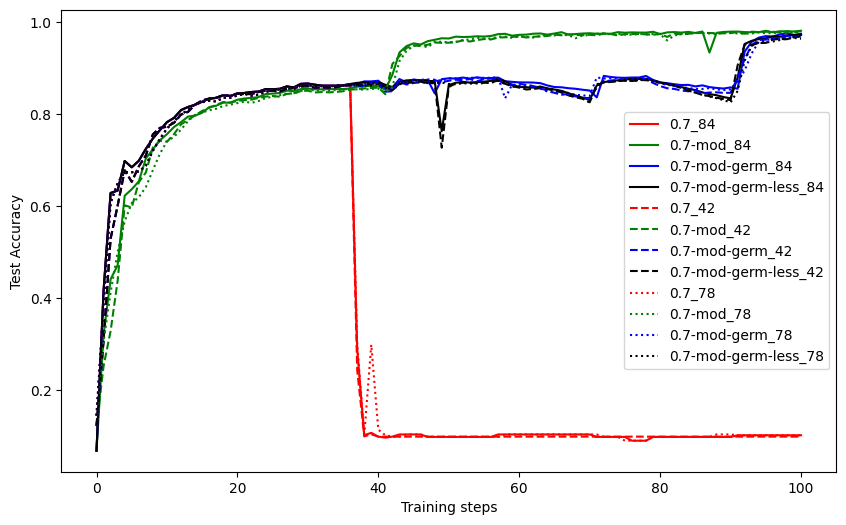

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(test_accuracy_values1,'r', label='0.7_84')
plt.plot(test_accuracy_values2,'g', label='0.7-mod_84')
plt.plot(test_accuracy_values3,'b', label='0.7-mod-germ_84')
plt.plot(test_accuracy_values4,'k', label='0.7-mod-germ-less_84')

plt.plot(test_accuracy_values5,'r',linestyle='dashed', label='0.7_42')
plt.plot(test_accuracy_values6,'g',linestyle='dashed', label='0.7-mod_42')
plt.plot(test_accuracy_values7,'b',linestyle='dashed', label='0.7-mod-germ_42')
plt.plot(test_accuracy_values8,'k',linestyle='dashed', label='0.7-mod-germ-less_42')

plt.plot(test_accuracy_values9,'r',linestyle='dotted', label='0.7_78')
plt.plot(test_accuracy_values10,'g',linestyle='dotted', label='0.7-mod_78')
plt.plot(test_accuracy_values11,'b',linestyle='dotted', label='0.7-mod-germ_78')
plt.plot(test_accuracy_values12,'k',linestyle='dotted', label='0.7-mod-germ-less_78')
plt.xlabel("Training steps")
plt.ylabel("Test Accuracy")
plt.legend()

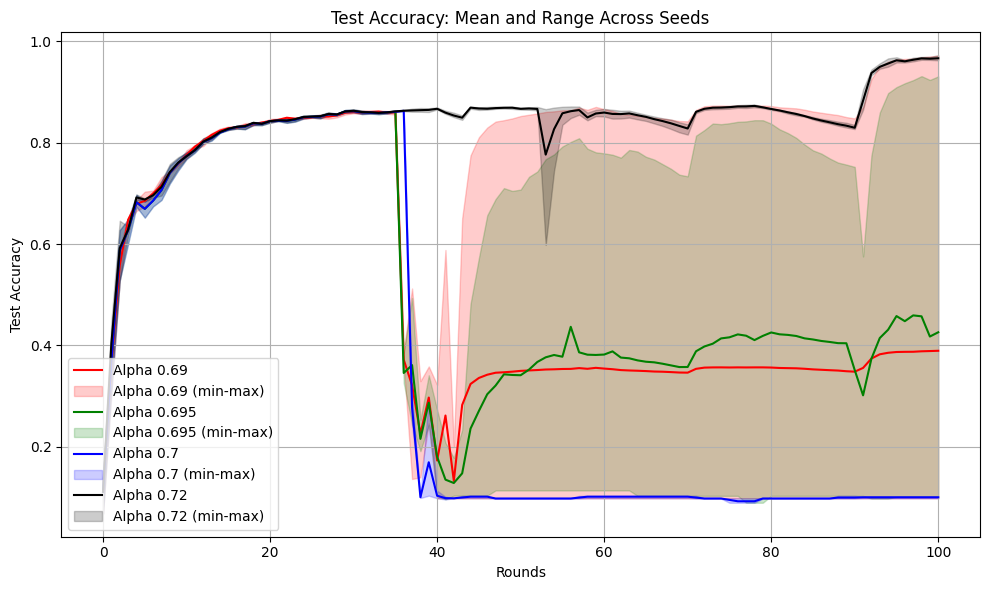

In [73]:
# File paths and parameters
seeds = [84, 42, 78]
alphas = [0.69, 0.695, 0.7, 0.72]
colors = ['r', 'g', 'b', 'k']

# Initialize data storage
alpha_data = {alpha: [] for alpha in alphas}

# Load data for all alphas and seeds
for alpha in alphas:
    for seed in seeds:
        file_path = f"../logs/mnist_server/alphaF-{alpha}cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.05/seed_{seed}/train/global"
        _, test_accuracy_values = parse_tf_events_file(file_path, tag="Test/Metric")
        alpha_data[alpha].append(test_accuracy_values)

# Plot the mean and range
plt.figure(figsize=(10, 6))

for alpha, color in zip(alphas, colors):
    # Convert list of lists to NumPy array for easy computation
    data = np.array(alpha_data[alpha])
    
    # Compute mean, min, and max across seeds
    mean_values = np.mean(data, axis=0)
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Plot mean line
    plt.plot(mean_values, color=color, label=f"Alpha {alpha}")
    
    # Fill between min and max for range
    plt.fill_between(
        range(len(mean_values)), min_values, max_values,
        color=color, alpha=0.2, label=f"Alpha {alpha} (min-max)"
    )

# Add legend, title, labels, and grid
plt.legend()
plt.title("Test Accuracy: Mean and Range Across Seeds")
plt.xlabel("Rounds")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


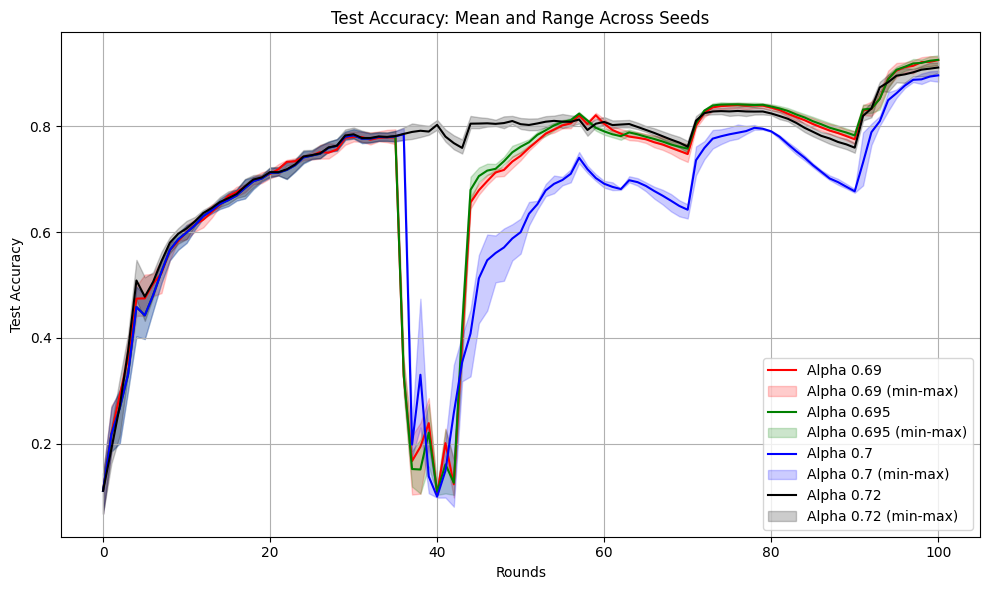

In [133]:
# File paths and parameters
seeds = [84, 42, 78]
alphas = [0.69, 0.695, 0.7, 0.72]
colors = ['r', 'g', 'b', 'k']

# Initialize data storage
alpha_data = {alpha: [] for alpha in alphas}

# Load data for all alphas and seeds
for alpha in alphas:
    for seed in seeds:
        file_path = f"../logs/mnist_server/alphaF-{alpha}cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.01/seed_{seed}/train/global"
        _, test_accuracy_values = parse_tf_events_file(file_path, tag="Test/Metric")
        alpha_data[alpha].append(test_accuracy_values)

# Plot the mean and range
plt.figure(figsize=(10, 6))

for alpha, color in zip(alphas, colors):
    # Convert list of lists to NumPy array for easy computation
    data = np.array(alpha_data[alpha])
    
    # Compute mean, min, and max across seeds
    mean_values = np.mean(data, axis=0)
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Plot mean line
    plt.plot(mean_values, color=color, label=f"Alpha {alpha}")
    
    # Fill between min and max for range
    plt.fill_between(
        range(len(mean_values)), min_values, max_values,
        color=color, alpha=0.2, label=f"Alpha {alpha} (min-max)"
    )

# Add legend, title, labels, and grid
plt.legend()
plt.title("Test Accuracy: Mean and Range Across Seeds")
plt.xlabel("Rounds")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


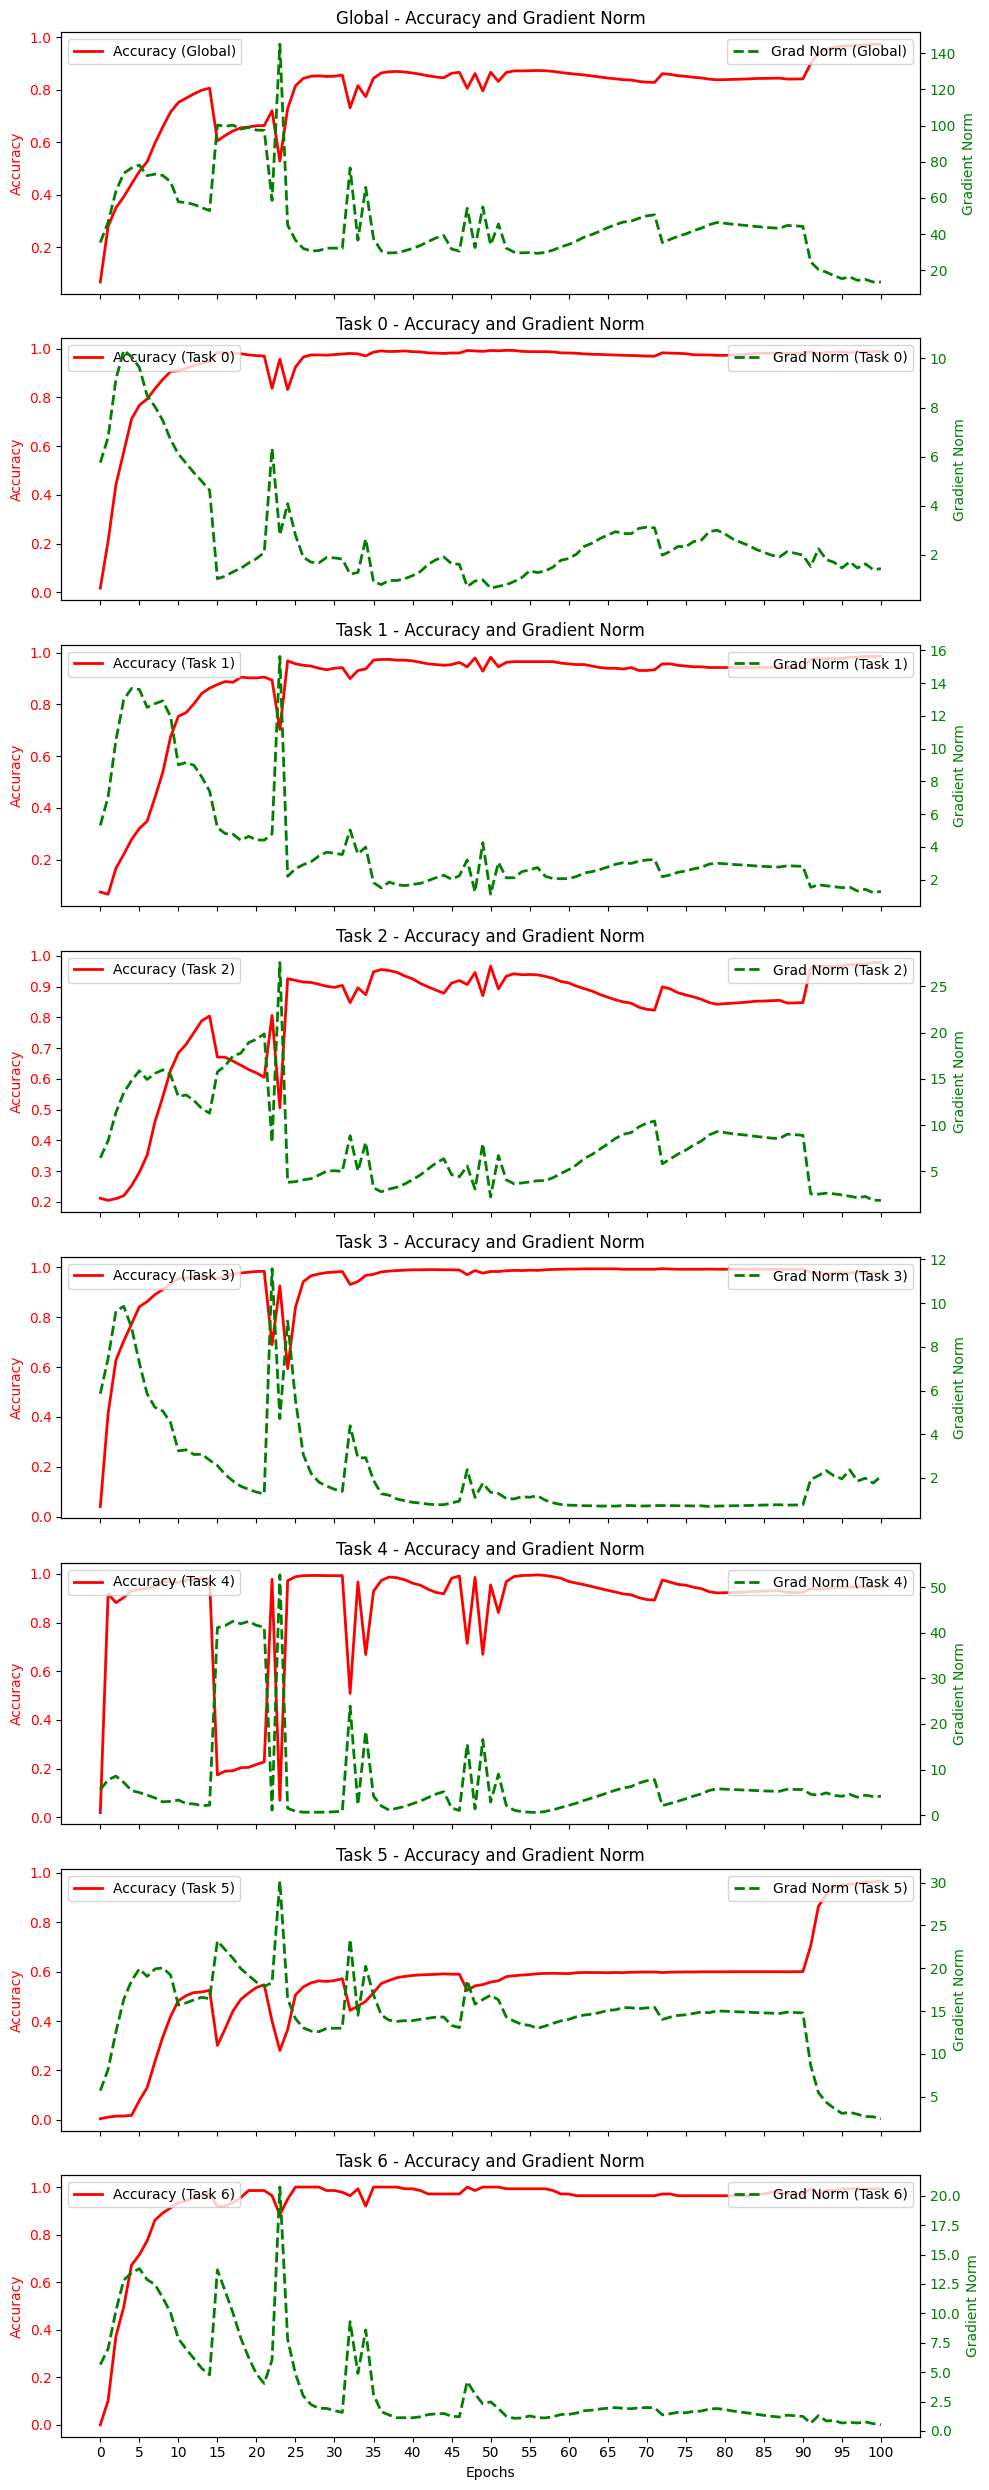

In [42]:
alp = "7"
_, test_acc_global = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/global", tag="Test/Metric")
_, test_global_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/global", tag="Test/GradNorm")
_, test_acc_1 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_0", tag="Test/Metric")
_, test_1_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_0", tag="Test/GradNorm")
_, test_acc_2 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_1", tag="Test/Metric")
_, test_2_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_1", tag="Test/GradNorm")
_, test_acc_3 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_2", tag="Test/Metric")
_, test_3_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_2", tag="Test/GradNorm")
_, test_acc_4 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_3", tag="Test/Metric")
_, test_4_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_3", tag="Test/GradNorm")
_, test_acc_5 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_4", tag="Test/Metric")
_, test_5_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_4", tag="Test/GradNorm")
_, test_acc_6 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_5", tag="Test/Metric")
_, test_6_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_5", tag="Test/GradNorm")
_, test_acc_7 = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_6", tag="Test/Metric")
_, test_7_grad = parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{alp}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_84/train/task_6", tag="Test/GradNorm")

# Create a figure with 8 subplots (one for each task, including the global one)
fig, axs = plt.subplots(8, 1, figsize=(10, 25), sharex=True)

# Define the data and labels for each subplot
tasks = [
    ("Global", test_acc_global, test_global_grad),
    ("Task 0", test_acc_1, test_1_grad),
    ("Task 1", test_acc_2, test_2_grad),
    ("Task 2", test_acc_3, test_3_grad),
    ("Task 3", test_acc_4, test_4_grad),
    ("Task 4", test_acc_5, test_5_grad),
    ("Task 5", test_acc_6, test_6_grad),
    ("Task 6", test_acc_7, test_7_grad),
]
x_values = np.arange(101)  # This will create an array from 0 to 100 (101 data points)
x_ticks = np.arange(0, 101, 5)  # This will create ticks every 5 epochs (0, 5, 10, ..., 100)
# Loop through each subplot and plot the data
for i, (task_name, acc_data, grad_data) in enumerate(tasks):
    ax1 = axs[i]  # Select the subplot

    # Plot accuracy on the left y-axis
    ax1.plot(acc_data, 'r', label=f'Accuracy ({task_name})', linewidth=2)
    ax1.set_ylabel('Accuracy', color='r')
    ax1.tick_params(axis='y', labelcolor='r')

    # Create the second y-axis for gradient norm
    ax2 = ax1.twinx()
    ax2.plot(grad_data, 'g', label=f'Grad Norm ({task_name})', linestyle='--', linewidth=2)
    ax2.set_ylabel('Gradient Norm', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    # Set title for each subplot
    ax1.set_title(f"{task_name} - Accuracy and Gradient Norm")

    # Set the x-ticks and labels on every subplot
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels(x_ticks)

    # Optional: Add legend to each subplot
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

# Set x-axis label for the bottom subplot
axs[-1].set_xlabel('Epochs')

# Adjust layout to prevent overlap
fig.tight_layout()

# Show the plot
plt.show()

In [2]:
_, test_accuracy_values1 = parse_tf_events_file("../logs/mnist_server/alphaF-0.8cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.01/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values2 = parse_tf_events_file("../logs/mnist_server/alphaF-0.82cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values3 = parse_tf_events_file("../logs/mnist_server/alphaF-0.84cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_84/train/global", tag="Test/Metric")
_, test_accuracy_values4 = parse_tf_events_file("../logs/mnist_server/alphaF-0.85cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_84/train/global", tag="Test/Metric")

_, test_accuracy_values5 = parse_tf_events_file("../logs/mnist_server/alphaF-0.8cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.01/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values6 = parse_tf_events_file("../logs/mnist_server/alphaF-0.82cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values7 = parse_tf_events_file("../logs/mnist_server/alphaF-0.84cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_42/train/global", tag="Test/Metric")
_, test_accuracy_values8 = parse_tf_events_file("../logs/mnist_server/alphaF-0.85cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_42/train/global", tag="Test/Metric")

_, test_accuracy_values9 = parse_tf_events_file("../logs/mnist_server/alphaF-0.8cb-10ft/biased_2/fedavg/alpha_0.1/lr_0.01/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values10 = parse_tf_events_file("../logs/mnist_server/alphaF-0.82cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values11 = parse_tf_events_file("../logs/mnist_server/alphaF-0.84cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_78/train/global", tag="Test/Metric")
_, test_accuracy_values12 = parse_tf_events_file("../logs/mnist_server/alphaF-0.85cb-10ft/biased_2/fedavg/alpha_0.1/lr_1e-2/seed_78/train/global", tag="Test/Metric")

NameError: name 'parse_tf_events_file' is not defined

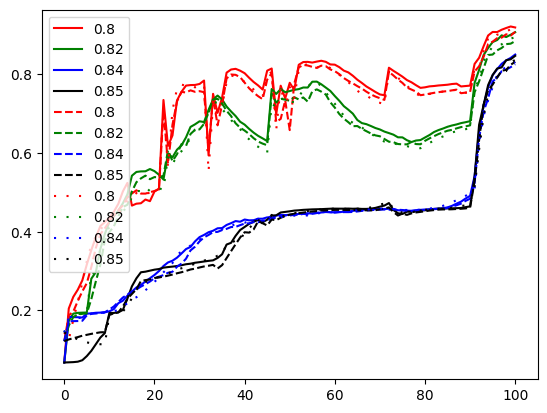

In [9]:
plt.plot(test_accuracy_values1,'r', label='0.8')
plt.plot(test_accuracy_values2,'g', label='0.82')
plt.plot(test_accuracy_values3,'b', label='0.84')
plt.plot(test_accuracy_values4,'k', label='0.85')

plt.plot(test_accuracy_values5,'r',linestyle='dashed', label='0.8')
plt.plot(test_accuracy_values6,'g',linestyle='dashed', label='0.82')
plt.plot(test_accuracy_values7,'b',linestyle='dashed', label='0.84')
plt.plot(test_accuracy_values8,'k',linestyle='dashed', label='0.85')

plt.plot(test_accuracy_values9,'r',linestyle=(0, (1, 5)), label='0.8')
plt.plot(test_accuracy_values10,'g',linestyle=(0, (1, 5)), label='0.82')
plt.plot(test_accuracy_values11,'b',linestyle=(0, (1, 5)), label='0.84')
plt.plot(test_accuracy_values12,'k',linestyle=(0, (1, 5)), label='0.85')

plt.legend()

0.9370999932289124
0.897599995136261
0.9070000052452087
0.9103999733924866
0.9086999893188477
0.9559000134468079
0.8687000274658203
0.8633000254631042
0.8661999702453613


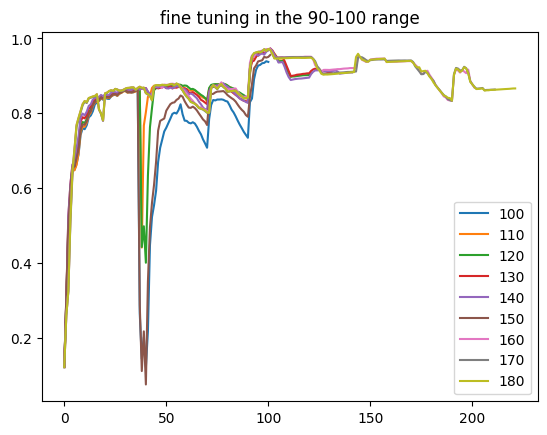

In [36]:
test_acc_global = {
    '100':parse_tf_events_file("../logs/mnist_server/128/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '110':parse_tf_events_file("../logs/mnist_server/128/alphaF-111sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '120':parse_tf_events_file("../logs/mnist_server/128/alphaF-121sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '130':parse_tf_events_file("../logs/mnist_server/128/alphaF-131sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '140':parse_tf_events_file("../logs/mnist_server/128/alphaF-141sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '150':parse_tf_events_file("../logs/mnist_server/128/alphaF-101sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '160':parse_tf_events_file("../logs/mnist_server/128/alphaF-201sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '170':parse_tf_events_file("../logs/mnist_server/128/alphaF-211sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1],
    '180':parse_tf_events_file("../logs/mnist_server/128/alphaF-221sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1]
}
for k, v in test_acc_global.items():
    plt.plot(v, label=k)
    print(v[-1])
plt.title("fine tuning in the 90-100 range")
plt.legend()
plt.show()


2025-02-17 10:16:50.560323: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 10:16:55.983143: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 10:17:00.666861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-17 10:17:04.472672: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-17 10:17:05.518488: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-17 10:17:12.458191: I tensorflow/core/platform/cpu_feature_gu

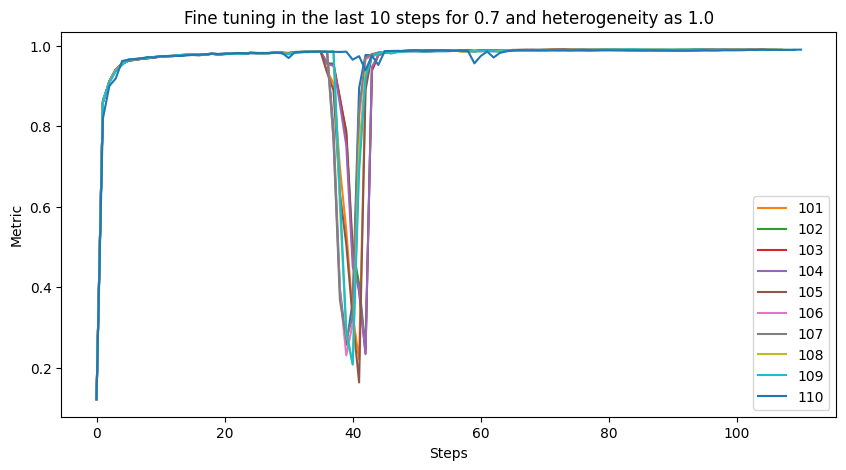

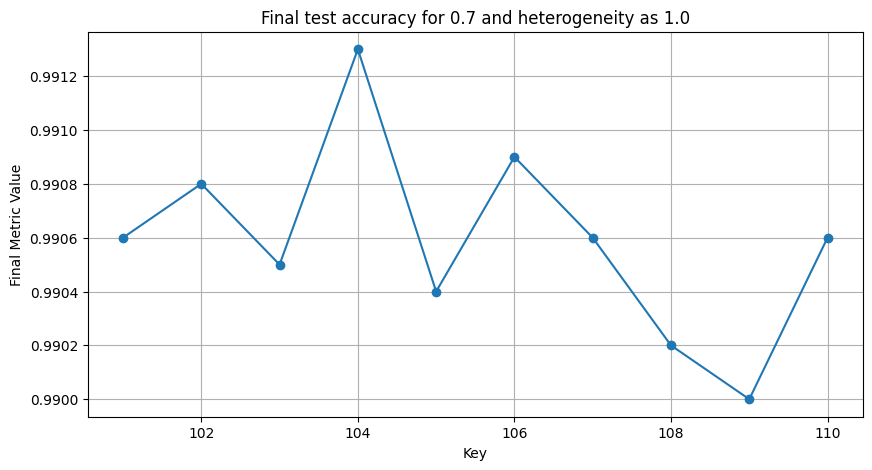

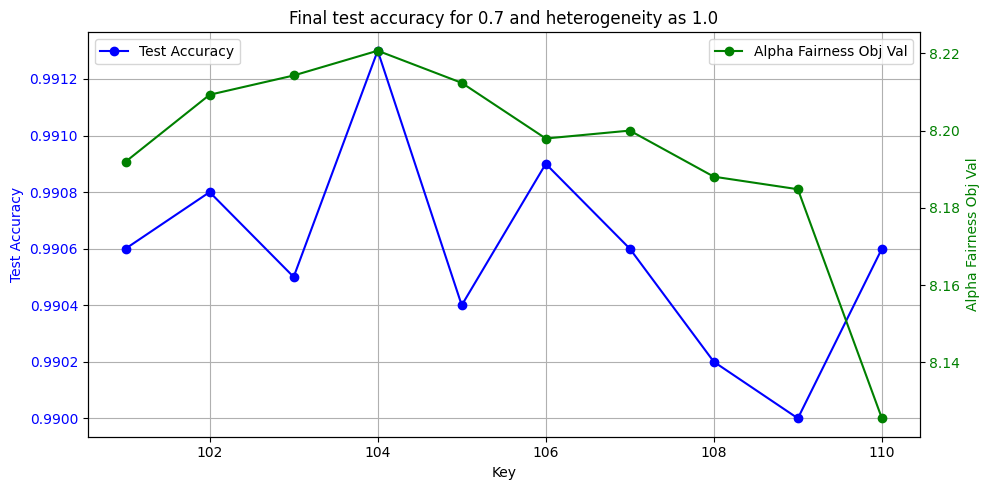

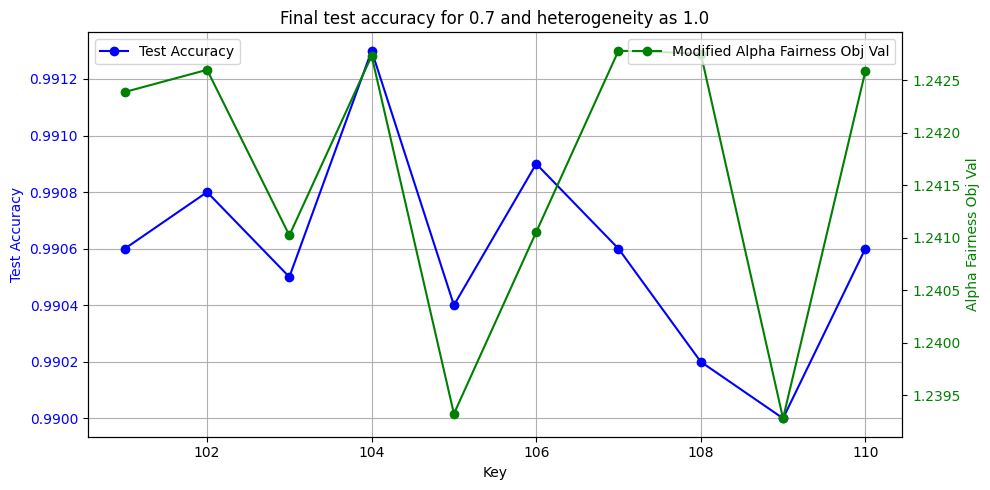

In [6]:
val = "7"

keys = [str(x) for x in range(101, 111, 1)]
test_acc_global = {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.{val}cb-10ft/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1]
    for k in keys
}
plt.figure(figsize=(10, 5))
plt.plot(parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{val}cb-10ft/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1])
for k, v in test_acc_global.items():
    plt.plot(v, label=k)

plt.legend()
plt.title(f"Fine tuning in the last 10 steps for 0.{val} and heterogeneity as 1.0")
plt.xlabel("Steps")
plt.ylabel("Metric")
plt.show()

# Plot the last values
plt.figure(figsize=(10, 5))
last_values = {int(k): v[-1] for k, v in test_acc_global.items()}
plt.plot(last_values.keys(), last_values.values(), marker="o")
plt.title(f"Final test accuracy for 0.{val} and heterogeneity as 1.0")
plt.xlabel("Key")
plt.ylabel("Final Metric Value")
plt.grid()
plt.show()


alpha_fairness_values = [8.191923788409277, 8.209246223252151, 8.214228480984438, 8.220636573958451, 8.212320578093344, 8.197930845867965, 8.199976498159531, 8.188056236331962, 8.184809393600265, 8.12555159227347]
mod_alpha_fairness = [1.2423902615949847,
 1.242601910426309,
 1.2410234977170809,
 1.2427350563443935,
 1.2393227331838115,
 1.2410549716290729,
 1.2427838914164282,
 1.2427572534112517,
 1.2392792923896505,
 1.2425861519038515]
fig, ax1 = plt.subplots(figsize=(10, 5))

# First series (blue)
ax1.plot(last_values.keys(), last_values.values(), marker="o", color="b", label="Test Accuracy")
ax1.set_xlabel("Key")
ax1.set_ylabel("Test Accuracy", color="b")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(last_values.keys(), alpha_fairness_values, color="g", label="Alpha Fairness Obj Val", marker="o")
ax2.set_ylabel("Alpha Fairness Obj Val", color="g")
ax2.tick_params(axis='y', labelcolor="g")

# Title and legends
plt.title(f"Final test accuracy for 0.{val} and heterogeneity as 1.0")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))

# First series (blue)
ax1.plot(last_values.keys(), last_values.values(), marker="o", color="b", label="Test Accuracy")
ax1.set_xlabel("Key")
ax1.set_ylabel("Test Accuracy", color="b")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(last_values.keys(), mod_alpha_fairness, color="g", label="Modified Alpha Fairness Obj Val", marker="o")
ax2.set_ylabel("Alpha Fairness Obj Val", color="g")
ax2.tick_params(axis='y', labelcolor="g")

# Title and legends
plt.title(f"Final test accuracy for 0.{val} and heterogeneity as 1.0")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()

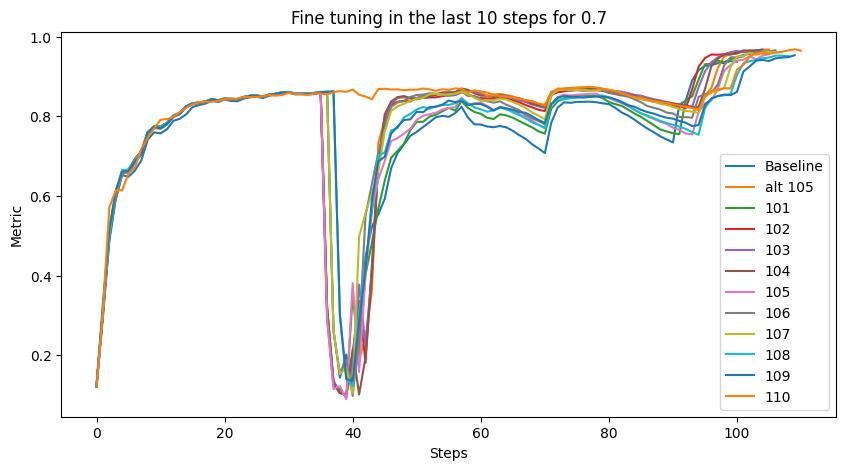

In [7]:
val = "7"

keys = [str(x) for x in range(101, 111, 1)]
test_acc_global = {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.{val}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1]
    for k in keys
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot reference curve
main_curve, = plt.plot(
    parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{val}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1], 
    label="Baseline"
)

gh, = plt.plot(
    parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.{val}cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1], 
    label="alt 105"
)

# Plot each dataset and store line objects
lines = {}  # Store line objects for reference
for k, v in test_acc_global.items():
    line, = plt.plot(v, label=k)  # Get line object
    lines[line] = k  # Map line object to its key

# Create legend
legend = plt.legend()
plt.title(f"Fine tuning in the last 10 steps for 0.{val}")
plt.xlabel("Steps")
plt.ylabel("Metric")

# Function to toggle visibility when legend is clicked
def on_legend_click(event):
    for legend_line, line in zip(legend.get_lines(), lines.keys()):  # Use get_lines()
        if event.artist == legend_line:
            visible = not line.get_visible()
            line.set_visible(visible)  # Toggle visibility
            legend_line.set_alpha(1.0 if visible else 0.2)  # Dim legend if hidden
            fig.canvas.draw()

# Make legend items pickable
for legend_line in legend.get_lines():  # Use get_lines() to access legend entries
    legend_line.set_picker(True)  # Enable picking on legend lines

# Connect event handler
fig.canvas.mpl_connect("pick_event", on_legend_click)

plt.show()

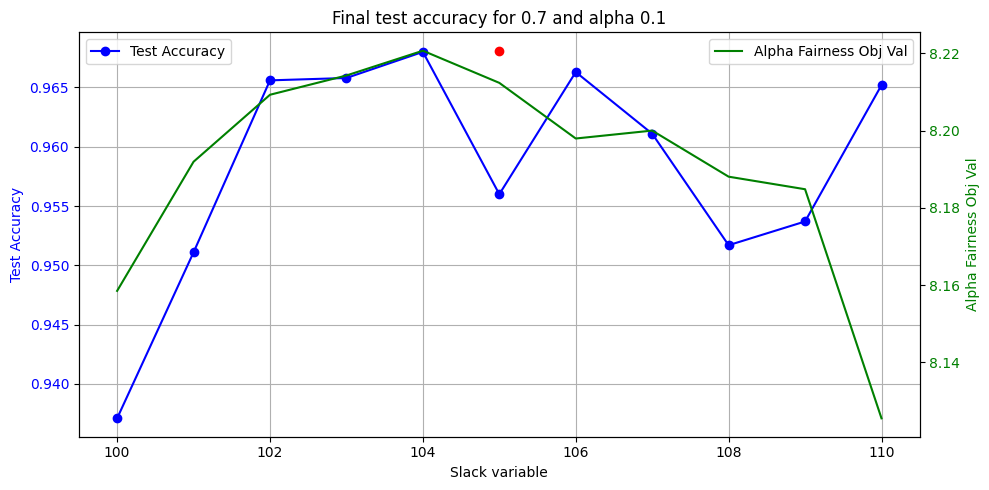

In [8]:
last_values = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}  
last_values.update(
    {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
}
)
alpha_fairness_values = [8.158516897216124, 8.191923788409277, 8.209246223252151, 8.214228480984438, 8.220636573958451, 8.212320578093344, 8.197930845867965, 8.199976498159531, 8.188056236331962, 8.184809393600265, 8.12555159227347]
fig, ax1 = plt.subplots(figsize=(10, 5))


# First series (blue)
ax1.plot(last_values.keys(), last_values.values(), marker="o", color="b", label="Test Accuracy")
ax1.plot(105, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.7cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Slack variable")
ax1.set_ylabel("Test Accuracy", color="b")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(last_values.keys(), alpha_fairness_values, color="g", label="Alpha Fairness Obj Val")
ax2.set_ylabel("Alpha Fairness Obj Val", color="g")
ax2.tick_params(axis='y', labelcolor="g")

# Title and legends
plt.title(f"Final test accuracy for 0.{val} and alpha 0.1")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()

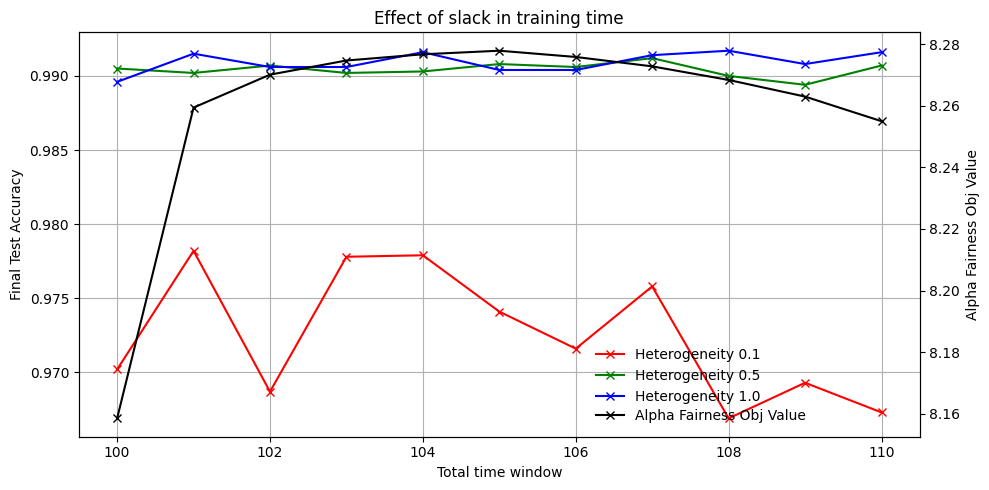

In [11]:
mod_av = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_av2 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av2.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_av1 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av1.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})



mod_obj_values = [8.158516897216124,8.259414877,8.270107828,8.274697214,8.276716441,8.277877665,8.275848612,8.272796755,8.26838824,8.26298049,8.254991784]
fig, ax1 = plt.subplots(figsize=(10, 5))


# First series (blue)
ax1.plot(mod_av.keys(), mod_av.values(), marker="x", color='r', label="Heterogeneity 0.1")
ax1.plot(mod_av2.keys(), mod_av2.values(), marker="x", color='g', label="Heterogeneity 0.5")
ax1.plot(mod_av1.keys(), mod_av1.values(), marker="x", color='b', label="Heterogeneity 1.0")
# ax1.plot(105, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.7cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Total time window")
ax1.set_ylabel("Final Test Accuracy")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(mod_av.keys(), mod_obj_values, marker="x", color="k", label="Alpha Fairness Obj Value")
ax2.set_ylabel("Alpha Fairness Obj Value")

# Title and legends
plt.title(f"Effect of slack in training time")
ax1.legend(loc='upper left', bbox_to_anchor=(0.6, 0.25), frameon=False)
ax2.legend(loc='upper left', bbox_to_anchor=(0.6, 0.1), frameon=False)
fig.tight_layout()
plt.show()




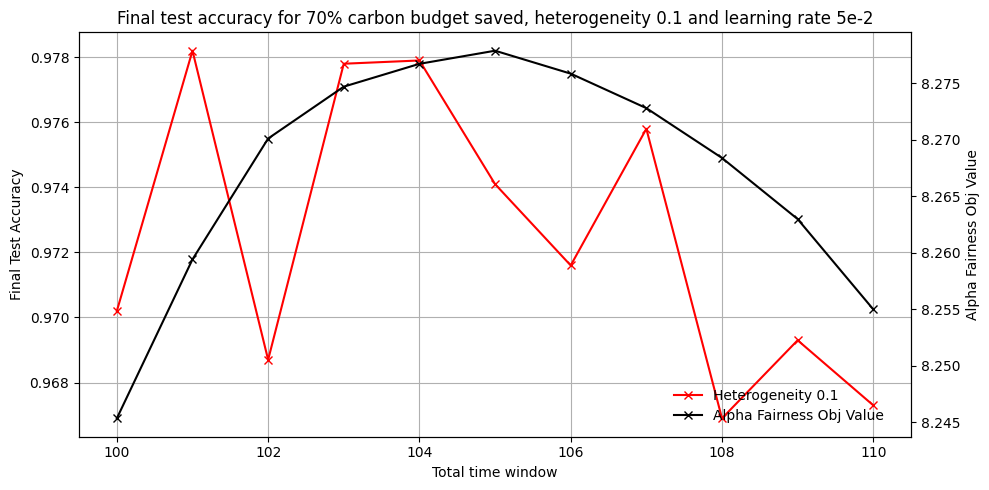

In [21]:
mod_av = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})




mod_obj_values = [8.24534762913218,8.259414877,8.270107828,8.274697214,8.276716441,8.277877665,8.275848612,8.272796755,8.26838824,8.26298049,8.254991784]
fig, ax1 = plt.subplots(figsize=(10, 5))


# First series (blue)
ax1.plot(mod_av.keys(), mod_av.values(), marker="x", color='r', label="Heterogeneity 0.1")
# ax1.plot(105, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.7cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Total time window")
ax1.set_ylabel("Final Test Accuracy")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(mod_av.keys(), mod_obj_values, marker="x", color="k", label="Alpha Fairness Obj Value")
ax2.set_ylabel("Alpha Fairness Obj Value")

# Title and legends
plt.title(f"Final test accuracy for 70% carbon budget saved, heterogeneity 0.1 and learning rate 5e-2")
ax1.legend(loc='upper left', bbox_to_anchor=(0.7, 0.15), frameon=False)
ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 0.1), frameon=False)
fig.tight_layout()
plt.show()




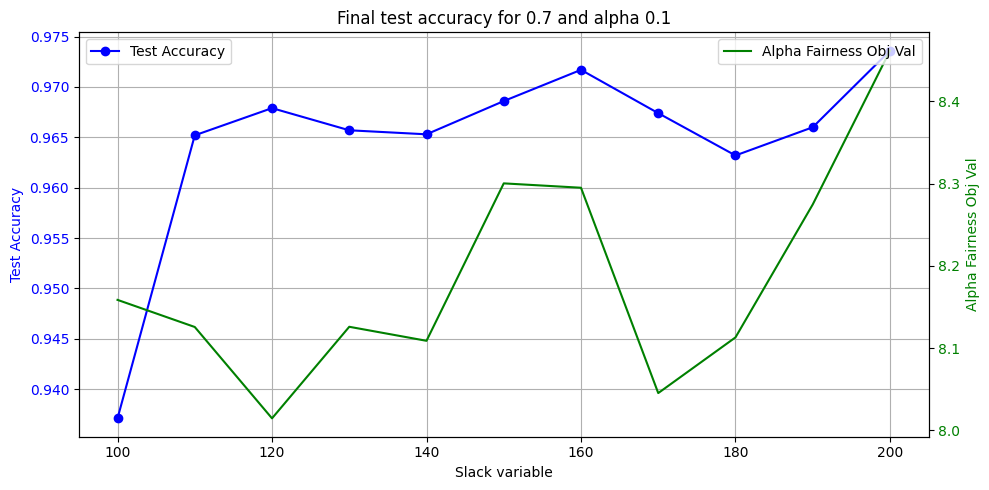

In [12]:
last_values = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}  
last_values.update(
    {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
}
)
alpha_fairness_values = [8.158516897216124, 8.125551592,8.014468544,8.125809876,8.108758065,8.300199212,8.294882377,8.045181364,8.112904345,8.274538897,8.461516299]
fig, ax1 = plt.subplots(figsize=(10, 5))


# First series (blue)
ax1.plot(last_values.keys(), last_values.values(), marker="o", color="b", label="Test Accuracy")
ax1.set_xlabel("Slack variable")
ax1.set_ylabel("Test Accuracy", color="b")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(last_values.keys(), alpha_fairness_values, color="g", label="Alpha Fairness Obj Val")
ax2.set_ylabel("Alpha Fairness Obj Val", color="g")
ax2.tick_params(axis='y', labelcolor="g")

# Title and legends
plt.title(f"Final test accuracy for 0.7 and alpha 0.1")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()


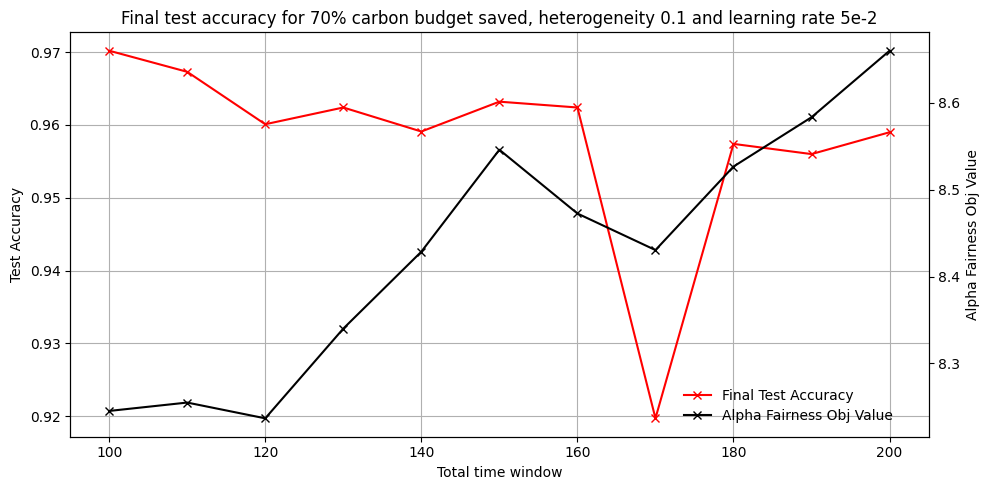

In [20]:
mod_av = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
})

mod_obj_values = [8.24534762913218,8.254991784,8.236837584,8.34007675,8.428570854,8.545886644,8.472515383,8.430439043,8.526524933,8.583287092,8.659804096]
fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.plot(mod_av.keys(), mod_av.values(), marker="x", color='r', label="Final Test Accuracy")
# ax1.plot(105, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.7cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Total time window")
ax1.set_ylabel("Test Accuracy")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(mod_av.keys(), mod_obj_values, marker="x", color="k", label="Alpha Fairness Obj Value")
ax2.set_ylabel("Alpha Fairness Obj Value")

# Title and legends
plt.title(f"Final test accuracy for 70% carbon budget saved, heterogeneity 0.1 and learning rate 5e-2")
ax1.legend(loc='upper left', bbox_to_anchor=(0.7, 0.15), frameon=False)
ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 0.1), frameon=False)
fig.tight_layout()
plt.show()

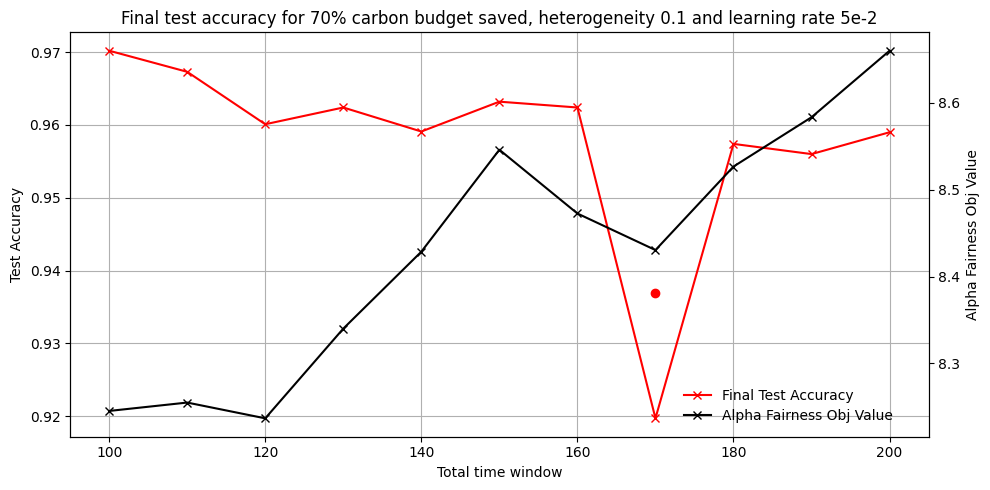

In [15]:
mod_av = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
})

mod_obj_values = [8.24534762913218,8.254991784,8.236837584,8.34007675,8.428570854,8.545886644,8.472515383,8.430439043,8.526524933,8.583287092,8.659804096]
fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.plot(mod_av.keys(), mod_av.values(), marker="x", color='r', label="Final Test Accuracy")
ax1.plot(170, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-170sl-0.7cb-10ft3/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Total time window")
ax1.set_ylabel("Test Accuracy")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(mod_av.keys(), mod_obj_values, marker="x", color="k", label="Alpha Fairness Obj Value")
ax2.set_ylabel("Alpha Fairness Obj Value")

# Title and legends
plt.title(f"Final test accuracy for 70% carbon budget saved, heterogeneity 0.1 and learning rate 5e-2")
ax1.legend(loc='upper left', bbox_to_anchor=(0.7, 0.15), frameon=False)
ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 0.1), frameon=False)
fig.tight_layout()
plt.show()

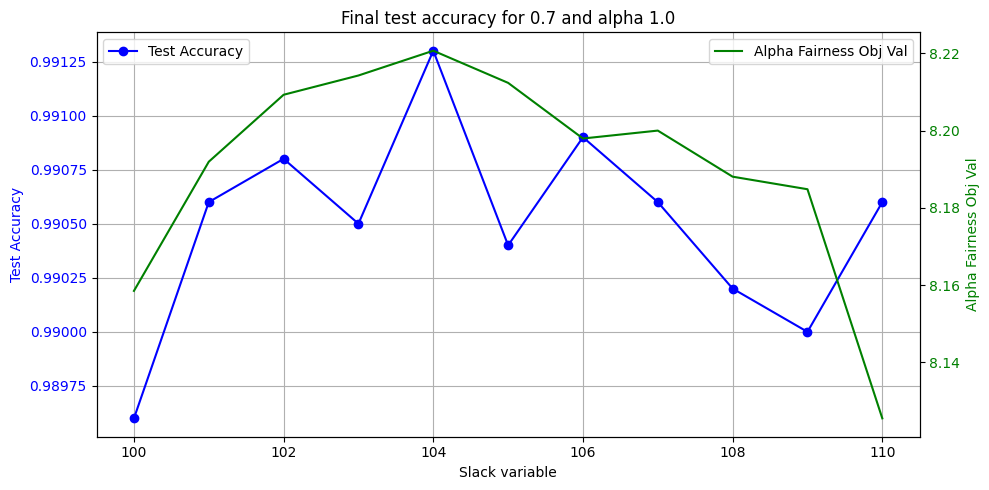

In [16]:
last_values = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}  
last_values.update(
    {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
}
)

alpha_fairness_values = [8.158516897216124, 8.191923788409277, 8.209246223252151, 8.214228480984438, 8.220636573958451, 8.212320578093344, 8.197930845867965, 8.199976498159531, 8.188056236331962, 8.184809393600265, 8.12555159227347]


fig, ax1 = plt.subplots(figsize=(10, 5))


# First series (blue)
ax1.plot(last_values.keys(), last_values.values(), marker="o", color="b", label="Test Accuracy")
ax1.set_xlabel("Slack variable")
ax1.set_ylabel("Test Accuracy", color="b")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(last_values.keys(), alpha_fairness_values, color="g", label="Alpha Fairness Obj Val")
ax2.set_ylabel("Alpha Fairness Obj Val", color="g")
ax2.tick_params(axis='y', labelcolor="g")

# Title and legends
plt.title(f"Final test accuracy for 0.7 and alpha 1.0")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()


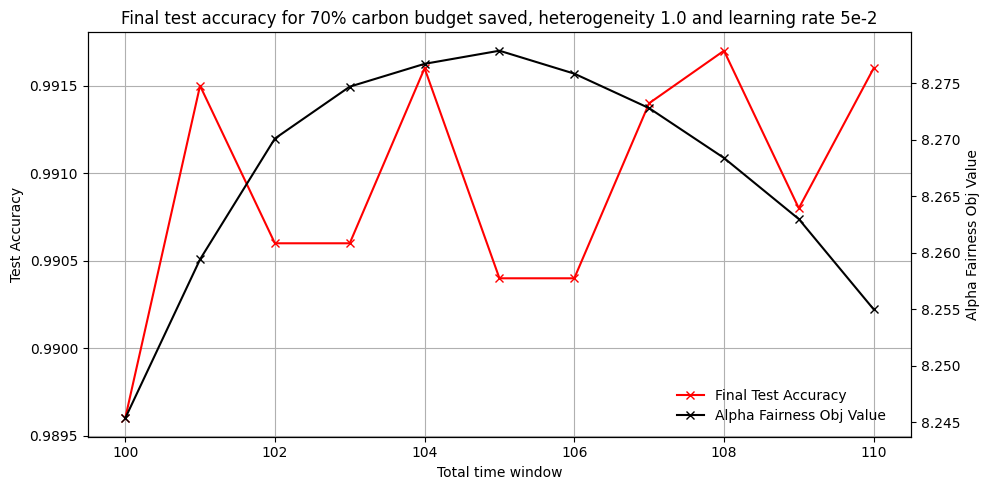

In [17]:

mod_av = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_obj_values = [8.24534762913218,8.259414877,8.270107828,8.274697214,8.276716441,8.277877665,8.275848612,8.272796755,8.26838824,8.26298049,8.254991784]

fig, ax1 = plt.subplots(figsize=(10, 5))

tmp = [1.24220063,       1.1948882848904978,1.2001292463324302,1.1978467930926324,1.1978675481390149,1.2050622005392377,1.2027308559477703,1.1954467028476463,1.1954094126710402,1.1927829616765024,1.1926754431656579       ]
# First series (blue)
ax1.plot(mod_av.keys(), mod_av.values(), marker="x", color='r', label="Final Test Accuracy")
# ax1.plot(105, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.7cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Total time window")
ax1.set_ylabel("Test Accuracy")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(mod_av.keys(), mod_obj_values, marker="x", color="k", label="Alpha Fairness Obj Value")
ax2.set_ylabel("Alpha Fairness Obj Value")

# Title and legends
plt.title(f"Final test accuracy for 70% carbon budget saved, heterogeneity 1.0 and learning rate 5e-2")
ax1.legend(loc='upper left', bbox_to_anchor=(0.7, 0.15), frameon=False)
ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 0.1), frameon=False)
fig.tight_layout()
plt.show()

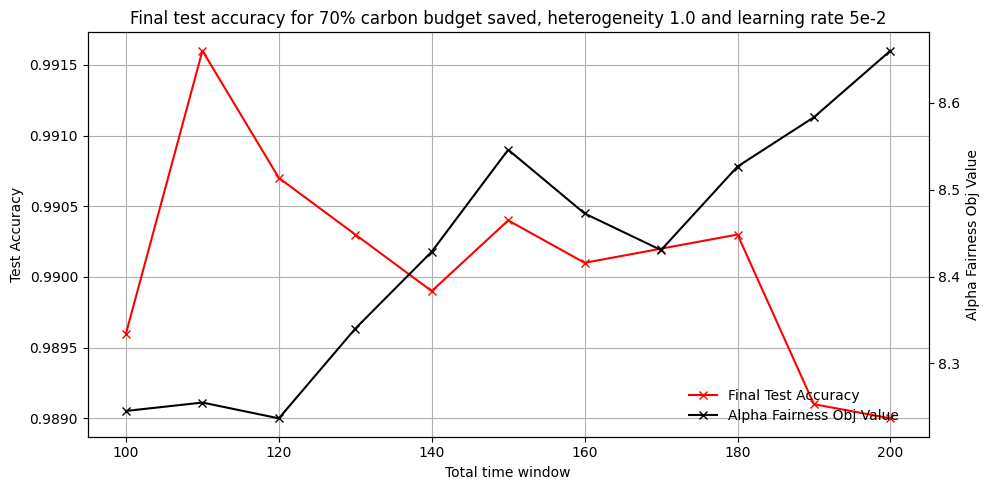

In [19]:

mod_av = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
})

mod_obj_values = [8.24534762913218,8.25499178398369, 8.236837584037783, 8.340076749847121, 8.42857085425416, 8.545886643567727, 8.472515383404641, 8.430439043475145, 8.526524932573238, 8.583287091525706, 8.659804095800489]

fig, ax1 = plt.subplots(figsize=(10, 5))


# First series (blue)
ax1.plot(mod_av.keys(), mod_av.values(), marker="x", color='r', label="Final Test Accuracy")
# ax1.plot(105, parse_tf_events_file(f"../logs/mnist_server/128/alphaF-105sl-0.7cb-10ft1/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1], "ro")
ax1.set_xlabel("Total time window")
ax1.set_ylabel("Test Accuracy")
ax1.grid()

# Second y-axis (green)
ax2 = ax1.twinx()
ax2.plot(mod_av.keys(), mod_obj_values, marker="x", color="k", label="Alpha Fairness Obj Value")
ax2.set_ylabel("Alpha Fairness Obj Value")

# Title and legends
plt.title(f"Final test accuracy for 70% carbon budget saved, heterogeneity 1.0 and learning rate 5e-2")
ax1.legend(loc='upper left', bbox_to_anchor=(0.7, 0.15), frameon=False)
ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 0.1), frameon=False)
fig.tight_layout()
plt.show()

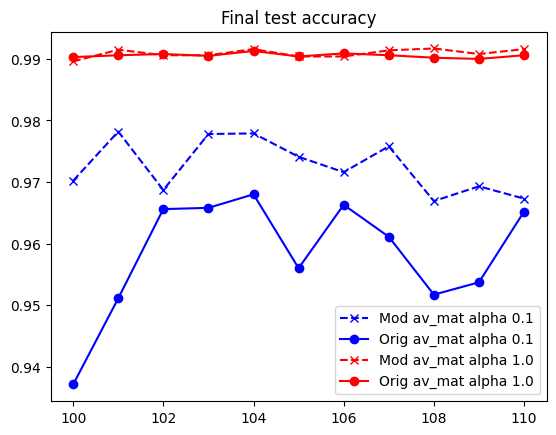

In [21]:
last_values_0_1 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
last_values_0_1.update(
    {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
}
)

mod_av_0_1 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_1.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

last_values_1_0 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
last_values_1_0.update(
    {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
}
)

mod_av_1_0 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_1_0.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

plt.figure()

plt.plot(mod_av_0_1.keys(), mod_av_0_1.values(), marker="x", color='b', linestyle="--",label="Mod av_mat alpha 0.1")
plt.plot(last_values_0_1.keys(), last_values_0_1.values(), marker="o", color="b", label="Orig av_mat alpha 0.1")


plt.plot(mod_av_1_0.keys(), mod_av_1_0.values(), marker="x", color='r', linestyle="--",label="Mod av_mat alpha 1.0")
plt.plot(last_values_1_0.keys(), last_values_1_0.values(), marker="o", color="r", label="Orig av_mat alpha 1.0")

# Title and legends
plt.title(f"Final test accuracy")
plt.legend()
plt.show()

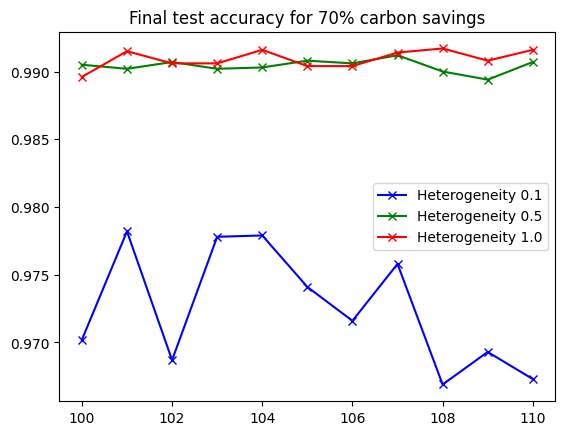

In [23]:
mod_av_0_1 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_1.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_av_0_5 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_5.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_av_1_0 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_1_0.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

plt.figure()

plt.plot(mod_av_0_1.keys(), mod_av_0_1.values(), marker="x", color='b', label="Heterogeneity 0.1")
plt.plot(mod_av_0_5.keys(), mod_av_0_5.values(), marker="x", color='g', label="Heterogeneity 0.5")
plt.plot(mod_av_1_0.keys(), mod_av_1_0.values(), marker="x", color='r', label="Heterogeneity 1.0")
# Title and legends
plt.title(f"Final test accuracy for 70% carbon savings")
plt.legend()
plt.show()

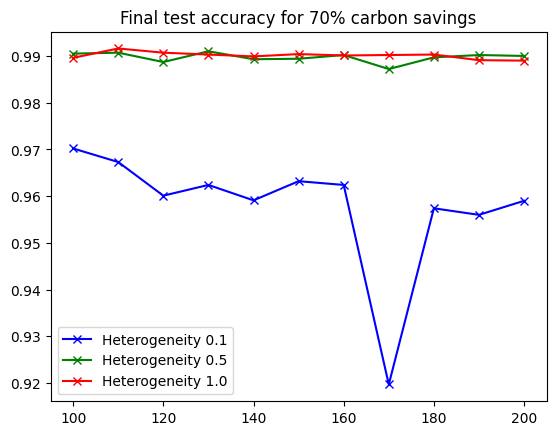

In [24]:
mod_av_0_1 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_1.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
})

mod_av_0_5 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_5.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
})

mod_av_1_0 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_1_0.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(110,201,10)
})

plt.figure()

plt.plot(mod_av_0_1.keys(), mod_av_0_1.values(), marker="x", color='b', label="Heterogeneity 0.1")
plt.plot(mod_av_0_5.keys(), mod_av_0_5.values(), marker="x", color='g', label="Heterogeneity 0.5")
plt.plot(mod_av_1_0.keys(), mod_av_1_0.values(), marker="x", color='r', label="Heterogeneity 1.0")
# Title and legends
plt.title(f"Final test accuracy for 70% carbon savings")
plt.legend()
plt.show()

In [ ]:
mod_av_0_1 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_1.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_av_0_5 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_0_5.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

mod_av_1_0 = {
    100: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
}
mod_av_1_0.update({
    k : parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.7cb-10ft2/biased_2/fedavg/alpha_1.0/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1][-1]
    for k in range(101,111,1)
})

plt.figure()

plt.plot(mod_av_0_1.keys(), mod_av_0_1.values(), marker="x", color='b', label="Heterogeneity 0.1")
plt.plot(mod_av_0_5.keys(), mod_av_0_5.values(), marker="x", color='g', label="Heterogeneity 0.5")
plt.plot(mod_av_1_0.keys(), mod_av_1_0.values(), marker="x", color='r', label="Heterogeneity 1.0")
# Title and legends
plt.title(f"Final test accuracy")
plt.legend()
plt.show()

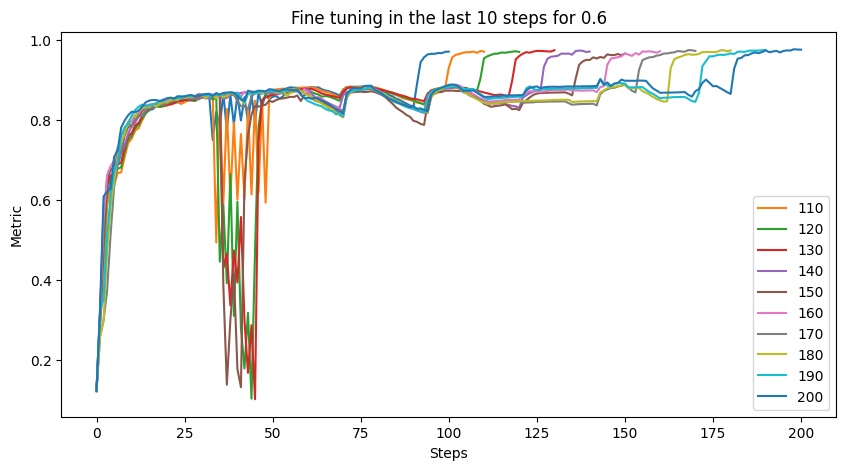

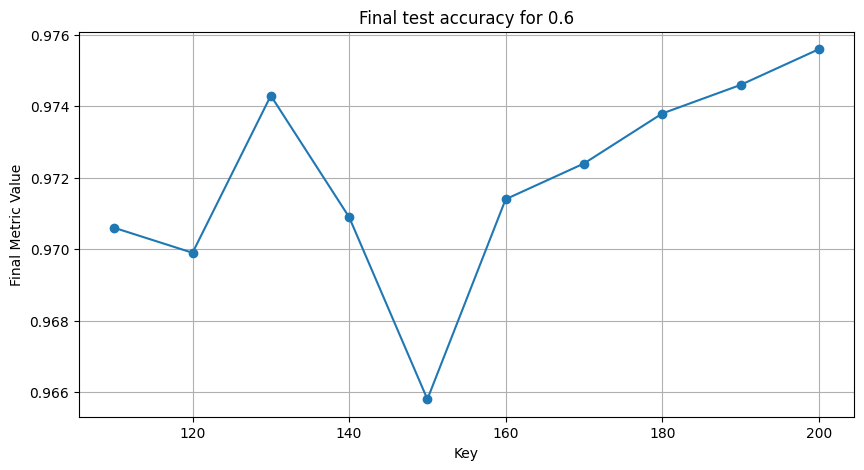

In [61]:
val = "6"

keys = [str(x) for x in range(110, 210, 10)]
test_acc_global = {
    k: parse_tf_events_file(f"../logs/mnist_server/128/alphaF-{k}sl-0.{val}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1]
    for k in keys
}
plt.figure(figsize=(10, 5))
plt.plot(parse_tf_events_file(f"../logs/mnist_server/128/alphaF-0.{val}cb-10ft/biased_2/fedavg/alpha_0.1/lr_5e-2/seed_42/train/global", tag="Test/Metric")[1])
for k, v in test_acc_global.items():
    plt.plot(v, label=k)

plt.legend()
plt.title(f"Fine tuning in the last 10 steps for 0.{val}")
plt.xlabel("Steps")
plt.ylabel("Metric")
plt.show()

# Plot the last values
plt.figure(figsize=(10, 5))
last_values = {int(k): v[-1] for k, v in test_acc_global.items()}
plt.plot(last_values.keys(), last_values.values(), marker="o")
plt.title(f"Final test accuracy for 0.{val}")
plt.xlabel("Key")
plt.ylabel("Final Metric Value")
plt.grid()
plt.show()

# With full data

/tmp/ipykernel_13914/4009612058.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)
/tmp/ipykernel_13914/4009612058.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)


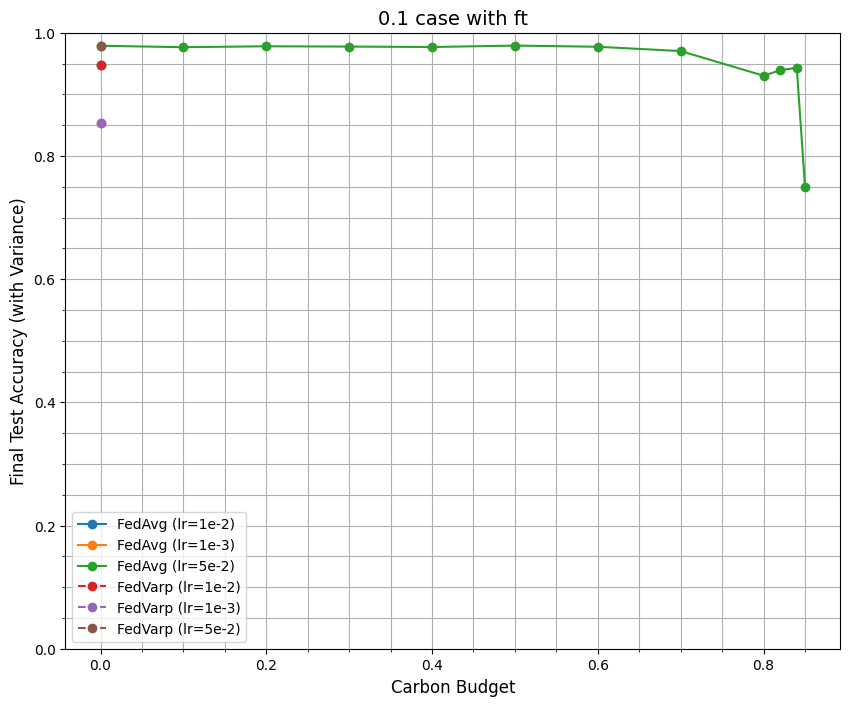

/tmp/ipykernel_13914/4009612058.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)
/tmp/ipykernel_13914/4009612058.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)


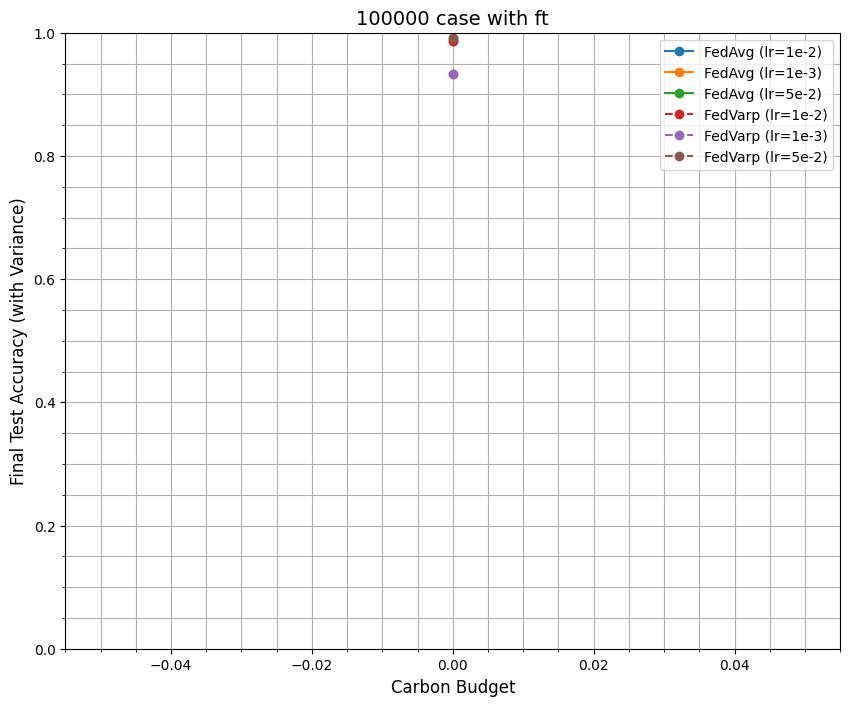

/tmp/ipykernel_13914/4009612058.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)
/tmp/ipykernel_13914/4009612058.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)


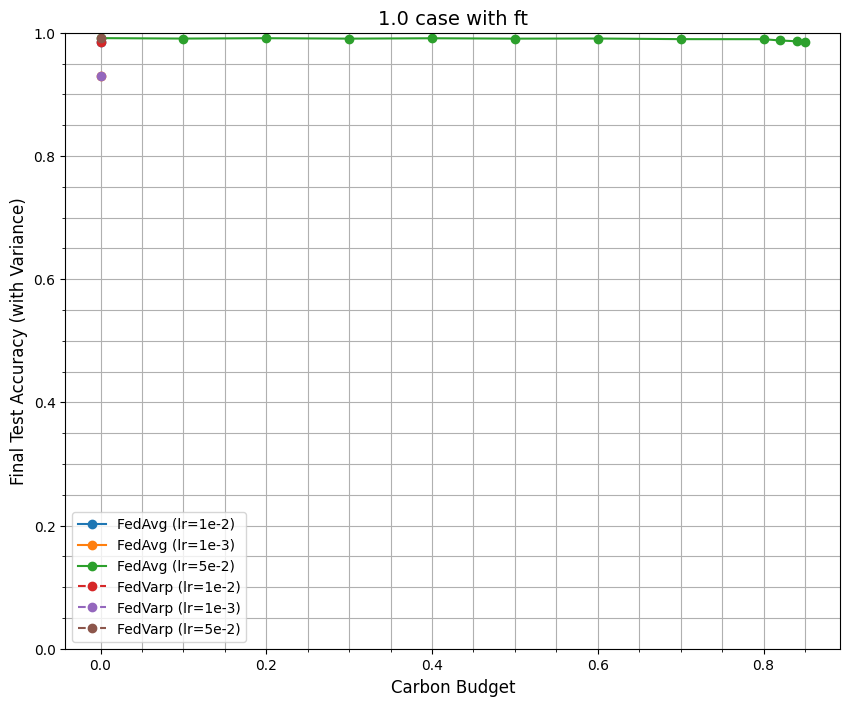

In [22]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42","78","84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["5e-2", "1e-2", "1e-3"],
    alphas=[NON_IID, IID, "1.0"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF-0.0cb-10ft-mod alphaF-0.1cb-10ft2 alphaF-0.2cb-10ft2 alphaF-0.3cb-10ft2 alphaF-0.4cb-10ft2 alphaF-0.5cb-10ft2 alphaF-0.6cb-10ft2 alphaF-0.7cb-10ft2 alphaF-0.8cb-10ft2 alphaF-0.82cb-10ft2 alphaF-0.84cb-10ft2 alphaF-0.85cb-10ft2".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)
get_plt(modify_data(_df=results_df), NON_IID, ft=True)
get_plt(modify_data(_df=results_df), IID, ft=True)
get_plt(modify_data(_df=results_df), "1.0", ft=True)

/tmp/ipykernel_35217/2330753569.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


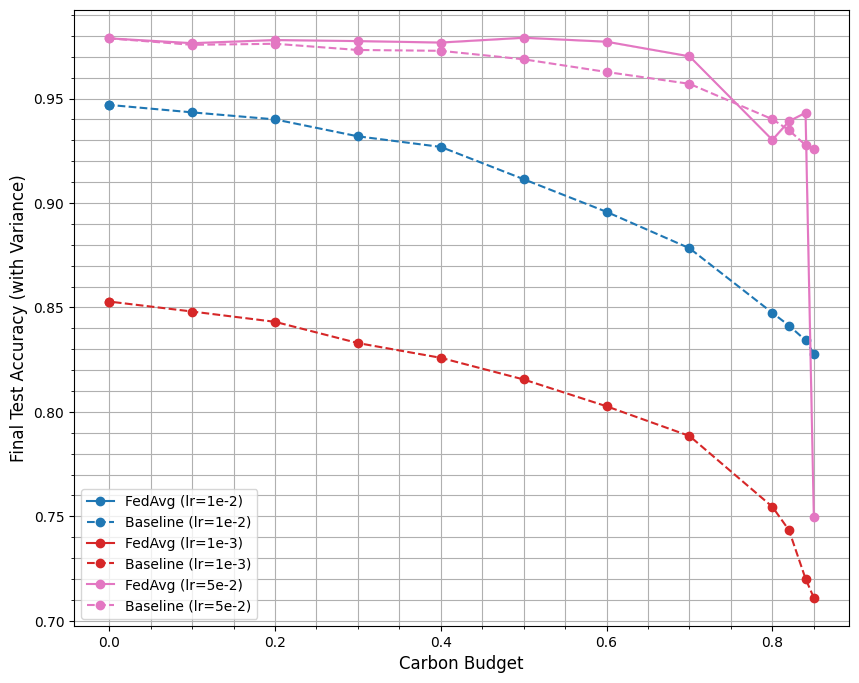

In [26]:
tmp = modify_data(results_df)
data_type = NON_IID
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

# Load baseline availability matrix and calculate list_0
_tmp = pd.read_csv(
    "../building_availability_matrices/availability_matrices/av-mat-5_av-mat-analysis/2022-01-01_00/av-mat_alphaF-0.0cb-10ft-mod.csv", 
    index_col=0
)
list_0 = [1 - _tmp[_tmp.columns[:i]].sum().sum() / _tmp.sum().sum() for i in [15, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90, 100]]

# Plotting
plt.figure(figsize=(10, 8))

# Define a colormap for consistent colors
colormap = plt.cm.tab10  # Or another colormap of your choice
unique_lr_values = fed_avg['lr'].unique()
color_map = {lr: colormap(i / len(unique_lr_values)) for i, lr in enumerate(unique_lr_values)}

# Plot FedAvg and Baseline for each learning rate
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Extract baseline data (dummy placeholder logic; replace with actual calculation)
    _tmp1 = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0].take([15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    
    # Plot FedAvg (solid line)
    plt.plot(
        subset['avail_mat'], subset['final_mean_acc'], 
        marker='o', label=f'FedAvg (lr={lr_value})', 
        color=color_map[lr_value], linestyle='-'
    )
    plt.fill_between(
        subset['avail_mat'], 
        subset['final_mean_acc'] - subset['final_var_acc'], 
        subset['final_mean_acc'] + subset['final_var_acc'], 
        alpha=0.2, color=color_map[lr_value]
    )
    
    # Plot Baseline (dashed line)
    plt.plot(
        list_0, _tmp1, 
        marker='o', label=f'Baseline (lr={lr_value})', 
        color=color_map[lr_value], linestyle='--'
    )

# Add labels, legend, and other plot details
plt.xlabel('Carbon Budget', fontsize=12)
plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()  # Enable minor ticks for finer granularity
plt.legend()
plt.show()

/tmp/ipykernel_35217/4247042691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


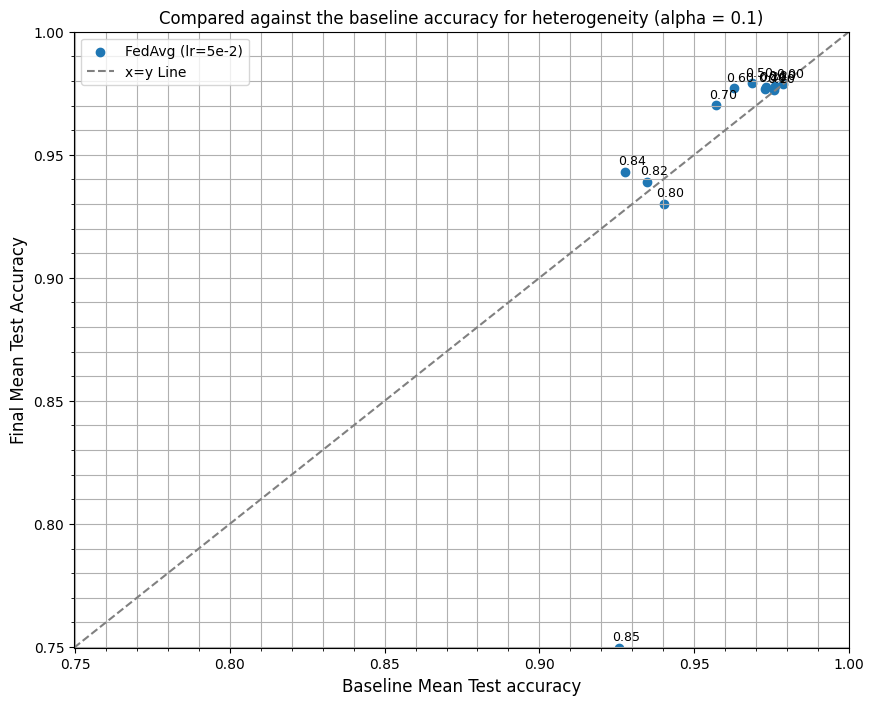

In [27]:
tmp = modify_data(results_df)
data_type = NON_IID
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

/tmp/ipykernel_35217/1243487959.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


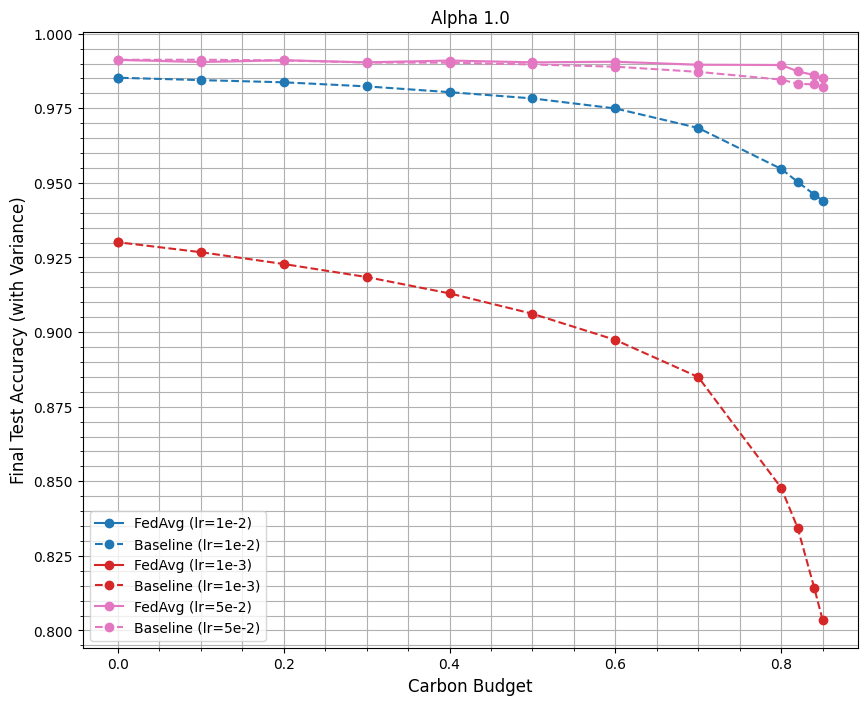

In [28]:
tmp = modify_data(results_df)
data_type = "1.0"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

# Load baseline availability matrix and calculate list_0
_tmp = pd.read_csv(
    "../building_availability_matrices/availability_matrices/av-mat-5_av-mat-analysis/2022-01-01_00/av-mat_alphaF-0.0cb-10ft-mod.csv", 
    index_col=0
)
list_0 = [1 - _tmp[_tmp.columns[:i]].sum().sum() / _tmp.sum().sum() for i in [15, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90, 100]]

# Plotting
plt.figure(figsize=(10, 8))

# Define a colormap for consistent colors
colormap = plt.cm.tab10  # Or another colormap of your choice
unique_lr_values = fed_avg['lr'].unique()
color_map = {lr: colormap(i / len(unique_lr_values)) for i, lr in enumerate(unique_lr_values)}

# Plot FedAvg and Baseline for each learning rate
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Extract baseline data (dummy placeholder logic; replace with actual calculation)
    _tmp1 = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0].take([15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    
    # Plot FedAvg (solid line)
    plt.plot(
        subset['avail_mat'], subset['final_mean_acc'], 
        marker='o', label=f'FedAvg (lr={lr_value})', 
        color=color_map[lr_value], linestyle='-'
    )
    plt.fill_between(
        subset['avail_mat'], 
        subset['final_mean_acc'] - subset['final_var_acc'], 
        subset['final_mean_acc'] + subset['final_var_acc'], 
        alpha=0.2, color=color_map[lr_value]
    )
    
    # Plot Baseline (dashed line)
    plt.plot(
        list_0, _tmp1, 
        marker='o', label=f'Baseline (lr={lr_value})', 
        color=color_map[lr_value], linestyle='--'
    )

# Add labels, legend, and other plot details
plt.xlabel('Carbon Budget', fontsize=12)
plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()  # Enable minor ticks for finer granularity
plt.title("Alpha 1.0")
plt.legend()
plt.show()

/tmp/ipykernel_13914/50780243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


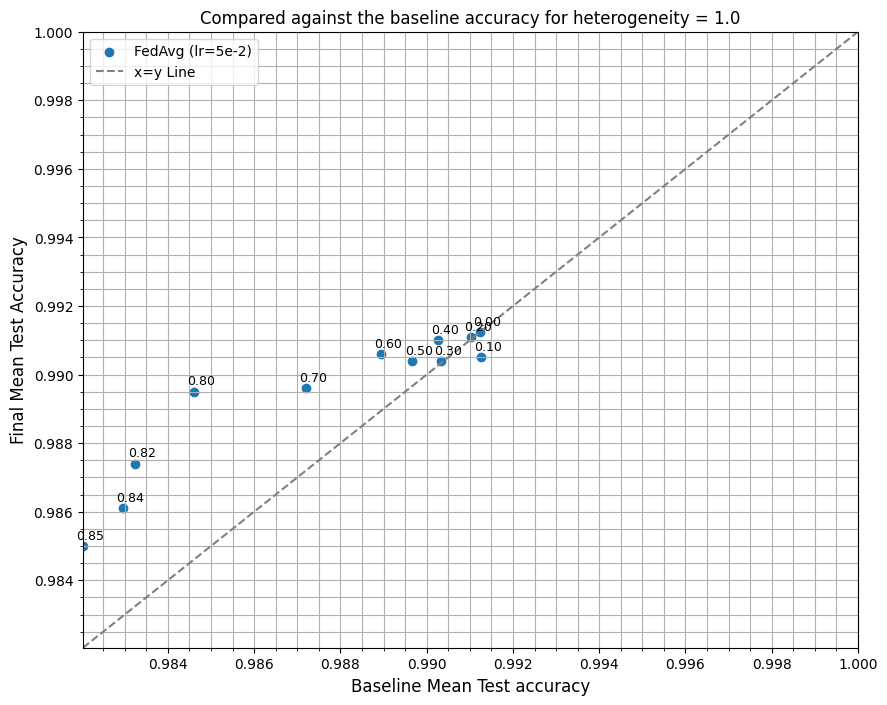

In [23]:
tmp = modify_data(results_df)
data_type = "1.0"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity = {data_type}")
plt.legend()
plt.show()

/tmp/ipykernel_15662/3360531088.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


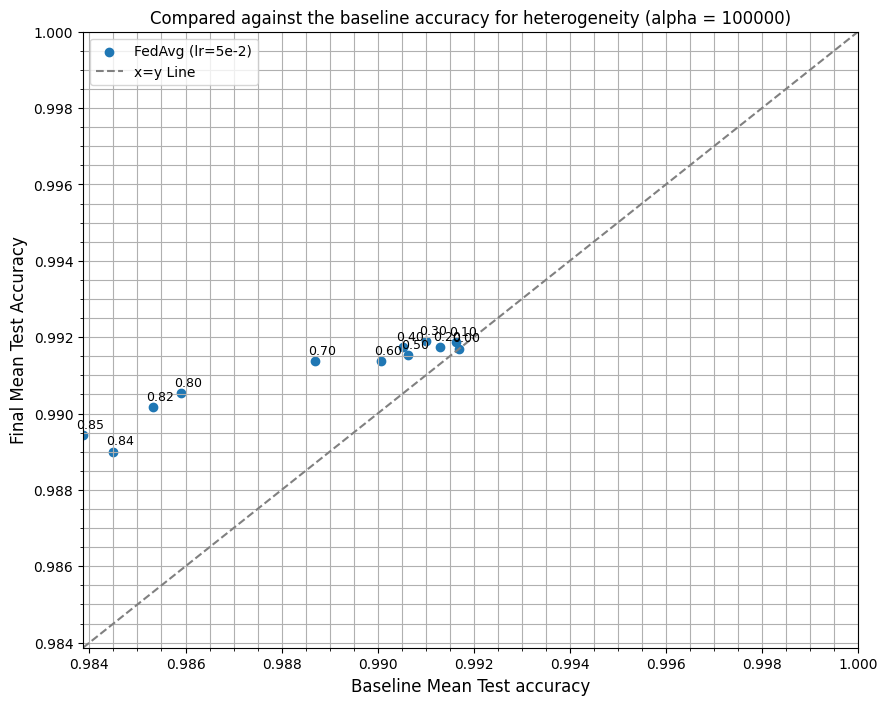

In [18]:
tmp = modify_data(results_df)
data_type = IID
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

In [42]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF-0.0cb-10ft-mod alphaF-0.1cb-10ft2 alphaF-0.2cb-10ft2 alphaF-0.3cb-10ft2 alphaF-0.4cb-10ft2 alphaF-0.5cb-10ft2 alphaF-0.6cb-10ft2 alphaF-0.7cb-10ft2 alphaF-0.8cb-10ft2 alphaF-0.82cb-10ft2 alphaF-0.84cb-10ft2 alphaF-0.85cb-10ft2".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

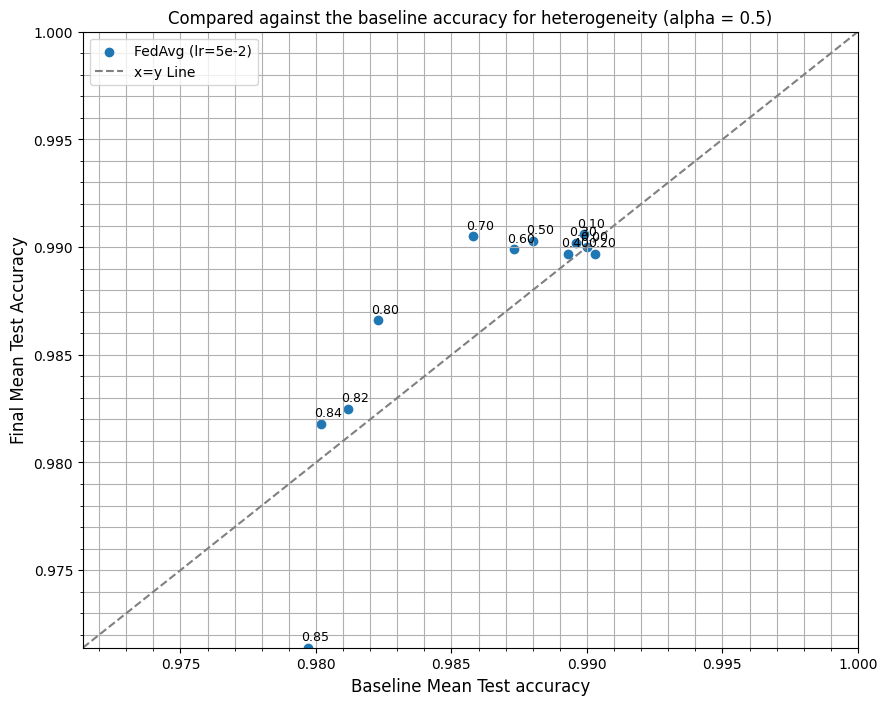

In [43]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

In [40]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5", "1.0"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF-0.0cb-10ft-mod alphaF-0.1cb-3ft2 alphaF-0.2cb-3ft2 alphaF-0.3cb-3ft2 alphaF-0.4cb-3ft2 alphaF-0.5cb-3ft2 alphaF-0.6cb-3ft2 alphaF-0.7cb-3ft2 alphaF-0.8cb-3ft2 alphaF-0.82cb-3ft2 alphaF-0.84cb-3ft2 alphaF-0.86cb-3ft2 alphaF-0.88cb-3ft2 alphaF-0.9cb-3ft2 alphaF-0.92cb-3ft2".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

In [82]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[8, 10, 12, 14, 16, 18, 20, 30,40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 1000x800 with 0 Axes>

# Analysis n rounds = 50

In [83]:
import os
from datetime import datetime, timedelta

def load_data(countries=None):
    """
    Loads the CI data in df_dict a dictionary where key=country, value=dataframe of CI data.
    Returns: df_dict
    The columns of each dataframe are datetime, CI_direct, CI_LA.
    The unit of the CI data is: gCO2eq/kWh.
    """

    # prepare links to the data csv files
    folder = "../building_availability_matrices/historical_data"
    _paths = {
        "Germany": os.path.join(folder, "DE_2022_hourly.csv"),
        "Austria": os.path.join(folder, "AT_2022_hourly.csv"),
        "Ireland": os.path.join(folder, "IE_2022_hourly.csv"),
        "Great Britain": os.path.join(folder, "GB_2022_hourly.csv"),
        "France": os.path.join(folder, "FR_2022_hourly.csv"),
        "Sweden": os.path.join(folder, "SE-SE3_2022_hourly.csv"),
        "Finland": os.path.join(folder, "FI_2022_hourly.csv"),
        "Belgium": os.path.join(folder, "BE_2022_hourly.csv"),
        "Brazil": os.path.join(folder, "BR_2022_hourly.csv"),
        "Denmark": os.path.join(folder, "DK_2022_hourly.csv"),
        "Estonia": os.path.join(folder, "EE_2022_hourly.csv"),
        "Spain": os.path.join(folder, "ES_2022_hourly.csv"),
        "Hungary": os.path.join(folder, "HU_2022_hourly.csv"),
        "Singapore": os.path.join(folder, "SG_2022_hourly.csv"),
        "Japan": os.path.join(folder, "JP_2022_hourly.csv"),
        "South Africa": os.path.join(folder, "ZA_2022_hourly.csv"),
        "Peru": os.path.join(folder, "PE_2022_hourly.csv"),
        "Croatia": os.path.join(folder, "HR_2022_hourly.csv"),
    }
    # loading the data in a pandas dataframe
    df_dict = {}
    usecols = [
        "Datetime (UTC)",
        "Carbon Intensity gCO₂eq/kWh (direct)",
        "Carbon Intensity gCO₂eq/kWh (LCA)",
    ]

    for key in countries if countries else _paths.keys():
        try:
            df_dict[key] = pd.read_csv(
                _paths[key], usecols=usecols, parse_dates=["Datetime (UTC)"]
            )
            df_dict[key] = df_dict[key].rename(
                columns={
                    "Datetime (UTC)": "datetime",
                    "Carbon Intensity gCO₂eq/kWh (direct)": "CI_direct",
                    "Carbon Intensity gCO₂eq/kWh (LCA)": "CI_LCA",
                }
            )
        except KeyError:
            print(f"Data for country {key} not present")
            continue

    return df_dict

In [84]:
countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"]
n_rounds = 50
dfs = load_data(countries)

start_time = datetime(2022, 1, 1, 0, 0)


CI_matrix = pd.DataFrame(
            index=countries, columns=[i for i in range(n_rounds)]
        )
for country in countries:
    CI_values = dfs[country][
            dfs[country]["datetime"].between(start_time, start_time + timedelta(hours=n_rounds - 1))
        ]["CI_direct"].values
    CI_matrix.loc[country, :] = CI_values

In [85]:
power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
GHG_matrix = CI_matrix * power * round_duration / 1000
total_cb = GHG_matrix.sum().sum()

In [86]:
# For 3 steps of fine tuning
carbon_budget_considered = GHG_matrix.sum().cumsum().to_numpy().take([44,39,34,29,24,19,14,9,8,4,3])
perc_cb_saved = np.insert(1 - carbon_budget_considered/total_cb, 0,0.0)


In [87]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-3ft alphaF50-2cb-3ft alphaF50-3cb-3ft alphaF50-4cb-3ft alphaF50-5cb-3ft alphaF50-6cb-3ft alphaF50-7cb-3ft alphaF50-8cb-3ft alphaF50-9cb-3ft alphaF50-10cb-3ft alphaF50-11cb-3ft alphaF50-200sl-10cb-3ft alphaF50-200sl-11cb-3ft alphaF50-200sl-1cb-3ft alphaF50-200sl-2cb-3ft alphaF50-200sl-3cb-3ft alphaF50-200sl-4cb-3ft alphaF50-200sl-5cb-3ft alphaF50-200sl-6cb-3ft alphaF50-200sl-7cb-3ft alphaF50-200sl-8cb-3ft alphaF50-200sl-9cb-3ft alphaF50-180sl-10cb-3ft alphaF50-180sl-11cb-3ft alphaF50-180sl-1cb-3ft alphaF50-180sl-2cb-3ft alphaF50-180sl-3cb-3ft alphaF50-180sl-4cb-3ft alphaF50-180sl-5cb-3ft alphaF50-180sl-6cb-3ft alphaF50-180sl-7cb-3ft alphaF50-180sl-8cb-3ft alphaF50-180sl-9cb-3ft alphaF50-160sl-10cb-3ft alphaF50-160sl-11cb-3ft alphaF50-160sl-1cb-3ft alphaF50-160sl-2cb-3ft alphaF50-160sl-3cb-3ft alphaF50-160sl-4cb-3ft alphaF50-160sl-5cb-3ft alphaF50-160sl-6cb-3ft alphaF50-160sl-7cb-3ft alphaF50-160sl-8cb-3ft alphaF50-160sl-9cb-3ft alphaF50-140sl-10cb-3ft alphaF50-140sl-11cb-3ft alphaF50-140sl-1cb-3ft alphaF50-140sl-2cb-3ft alphaF50-140sl-3cb-3ft alphaF50-140sl-4cb-3ft alphaF50-140sl-5cb-3ft alphaF50-140sl-6cb-3ft alphaF50-140sl-7cb-3ft alphaF50-140sl-8cb-3ft alphaF50-140sl-9cb-3ft alphaF50-120sl-10cb-3ft alphaF50-120sl-11cb-3ft alphaF50-120sl-1cb-3ft alphaF50-120sl-2cb-3ft alphaF50-120sl-3cb-3ft alphaF50-120sl-4cb-3ft alphaF50-120sl-5cb-3ft alphaF50-120sl-6cb-3ft alphaF50-120sl-7cb-3ft alphaF50-120sl-8cb-3ft alphaF50-120sl-9cb-3ft alphaF50-100sl-10cb-3ft alphaF50-100sl-11cb-3ft alphaF50-100sl-1cb-3ft alphaF50-100sl-2cb-3ft alphaF50-100sl-3cb-3ft alphaF50-100sl-4cb-3ft alphaF50-100sl-5cb-3ft alphaF50-100sl-6cb-3ft alphaF50-100sl-7cb-3ft alphaF50-100sl-8cb-3ft alphaF50-100sl-9cb-3ft alphaF50-90sl-10cb-3ft alphaF50-90sl-11cb-3ft alphaF50-90sl-1cb-3ft alphaF50-90sl-2cb-3ft alphaF50-90sl-3cb-3ft alphaF50-90sl-4cb-3ft alphaF50-90sl-5cb-3ft alphaF50-90sl-6cb-3ft alphaF50-90sl-7cb-3ft alphaF50-90sl-8cb-3ft alphaF50-90sl-9cb-3ft alphaF50-80sl-10cb-3ft alphaF50-80sl-11cb-3ft alphaF50-80sl-1cb-3ft alphaF50-80sl-2cb-3ft alphaF50-80sl-3cb-3ft alphaF50-80sl-4cb-3ft alphaF50-80sl-5cb-3ft alphaF50-80sl-6cb-3ft alphaF50-80sl-7cb-3ft alphaF50-80sl-8cb-3ft alphaF50-80sl-9cb-3ft alphaF50-70sl-10cb-3ft alphaF50-70sl-11cb-3ft alphaF50-70sl-1cb-3ft alphaF50-70sl-2cb-3ft alphaF50-70sl-3cb-3ft alphaF50-70sl-4cb-3ft alphaF50-70sl-5cb-3ft alphaF50-70sl-6cb-3ft alphaF50-70sl-7cb-3ft alphaF50-70sl-8cb-3ft alphaF50-70sl-9cb-3ft alphaF50-60sl-10cb-3ft alphaF50-60sl-11cb-3ft alphaF50-60sl-1cb-3ft alphaF50-60sl-2cb-3ft alphaF50-60sl-3cb-3ft alphaF50-60sl-4cb-3ft alphaF50-60sl-5cb-3ft alphaF50-60sl-6cb-3ft alphaF50-60sl-7cb-3ft alphaF50-60sl-8cb-3ft alphaF50-60sl-9cb-3ft alphaF50-59sl-10cb-3ft alphaF50-59sl-11cb-3ft alphaF50-59sl-1cb-3ft alphaF50-59sl-2cb-3ft alphaF50-59sl-3cb-3ft alphaF50-59sl-4cb-3ft alphaF50-59sl-5cb-3ft alphaF50-59sl-6cb-3ft alphaF50-59sl-7cb-3ft alphaF50-59sl-8cb-3ft alphaF50-59sl-9cb-3ft alphaF50-58sl-10cb-3ft alphaF50-58sl-11cb-3ft alphaF50-58sl-1cb-3ft alphaF50-58sl-2cb-3ft alphaF50-58sl-3cb-3ft alphaF50-58sl-4cb-3ft alphaF50-58sl-5cb-3ft alphaF50-58sl-6cb-3ft alphaF50-58sl-7cb-3ft alphaF50-58sl-8cb-3ft alphaF50-58sl-9cb-3ft alphaF50-57sl-10cb-3ft alphaF50-57sl-11cb-3ft alphaF50-57sl-1cb-3ft alphaF50-57sl-2cb-3ft alphaF50-57sl-3cb-3ft alphaF50-57sl-4cb-3ft alphaF50-57sl-5cb-3ft alphaF50-57sl-6cb-3ft alphaF50-57sl-7cb-3ft alphaF50-57sl-8cb-3ft alphaF50-57sl-9cb-3ft alphaF50-56sl-10cb-3ft alphaF50-56sl-11cb-3ft alphaF50-56sl-1cb-3ft alphaF50-56sl-2cb-3ft alphaF50-56sl-3cb-3ft alphaF50-56sl-4cb-3ft alphaF50-56sl-5cb-3ft alphaF50-56sl-6cb-3ft alphaF50-56sl-7cb-3ft alphaF50-56sl-8cb-3ft alphaF50-56sl-9cb-3ft alphaF50-55sl-10cb-3ft alphaF50-55sl-11cb-3ft alphaF50-55sl-1cb-3ft alphaF50-55sl-2cb-3ft alphaF50-55sl-3cb-3ft alphaF50-55sl-4cb-3ft alphaF50-55sl-5cb-3ft alphaF50-55sl-6cb-3ft alphaF50-55sl-7cb-3ft alphaF50-55sl-8cb-3ft alphaF50-55sl-9cb-3ft alphaF50-54sl-10cb-3ft alphaF50-54sl-11cb-3ft alphaF50-54sl-1cb-3ft alphaF50-54sl-2cb-3ft alphaF50-54sl-3cb-3ft alphaF50-54sl-4cb-3ft alphaF50-54sl-5cb-3ft alphaF50-54sl-6cb-3ft alphaF50-54sl-7cb-3ft alphaF50-54sl-8cb-3ft alphaF50-54sl-9cb-3ft alphaF50-53sl-10cb-3ft alphaF50-53sl-11cb-3ft alphaF50-53sl-1cb-3ft alphaF50-53sl-2cb-3ft alphaF50-53sl-3cb-3ft alphaF50-53sl-4cb-3ft alphaF50-53sl-5cb-3ft alphaF50-53sl-6cb-3ft alphaF50-53sl-7cb-3ft alphaF50-53sl-8cb-3ft alphaF50-53sl-9cb-3ft alphaF50-52sl-10cb-3ft alphaF50-52sl-11cb-3ft alphaF50-52sl-1cb-3ft alphaF50-52sl-2cb-3ft alphaF50-52sl-3cb-3ft alphaF50-52sl-4cb-3ft alphaF50-52sl-5cb-3ft alphaF50-52sl-6cb-3ft alphaF50-52sl-7cb-3ft alphaF50-52sl-8cb-3ft alphaF50-52sl-9cb-3ft alphaF50-51sl-10cb-3ft alphaF50-51sl-11cb-3ft alphaF50-51sl-1cb-3ft alphaF50-51sl-2cb-3ft alphaF50-51sl-3cb-3ft alphaF50-51sl-4cb-3ft alphaF50-51sl-5cb-3ft alphaF50-51sl-6cb-3ft alphaF50-51sl-7cb-3ft alphaF50-51sl-8cb-3ft alphaF50-51sl-9cb-3ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

alphaF50-0.0cb-3ft
alphaF50-1cb-3ft
alphaF50-2cb-3ft
alphaF50-3cb-3ft
alphaF50-4cb-3ft
alphaF50-5cb-3ft
alphaF50-6cb-3ft
alphaF50-7cb-3ft
alphaF50-8cb-3ft
alphaF50-9cb-3ft
alphaF50-10cb-3ft
alphaF50-11cb-3ft
alphaF50-200sl-10cb-3ft
alphaF50-200sl-11cb-3ft
alphaF50-200sl-1cb-3ft
alphaF50-200sl-2cb-3ft
alphaF50-200sl-3cb-3ft
alphaF50-200sl-4cb-3ft
alphaF50-200sl-5cb-3ft
alphaF50-200sl-6cb-3ft
alphaF50-200sl-7cb-3ft
alphaF50-200sl-8cb-3ft
alphaF50-200sl-9cb-3ft
alphaF50-180sl-10cb-3ft
alphaF50-180sl-11cb-3ft
alphaF50-180sl-1cb-3ft
alphaF50-180sl-2cb-3ft
alphaF50-180sl-3cb-3ft
alphaF50-180sl-4cb-3ft
alphaF50-180sl-5cb-3ft
alphaF50-180sl-6cb-3ft
alphaF50-180sl-7cb-3ft
alphaF50-180sl-8cb-3ft
alphaF50-180sl-9cb-3ft
alphaF50-160sl-10cb-3ft
alphaF50-160sl-11cb-3ft
alphaF50-160sl-1cb-3ft
alphaF50-160sl-2cb-3ft
alphaF50-160sl-3cb-3ft
alphaF50-160sl-4cb-3ft
alphaF50-160sl-5cb-3ft
alphaF50-160sl-6cb-3ft
alphaF50-160sl-7cb-3ft
alphaF50-160sl-8cb-3ft
alphaF50-160sl-9cb-3ft
alphaF50-140sl-10cb-3ft
alp

In [88]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(50).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)

In [89]:
alpha_test_acc_50 = fed_avg.loc[fed_avg['slack_time']==50].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100
alpha_test_acc_slack = {
    51: fed_avg.loc[fed_avg['slack_time']==51].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    52: fed_avg.loc[fed_avg['slack_time']==52].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    53: fed_avg.loc[fed_avg['slack_time']==53].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    54: fed_avg.loc[fed_avg['slack_time']==54].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    55: fed_avg.loc[fed_avg['slack_time']==55].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    56: fed_avg.loc[fed_avg['slack_time']==56].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    57: fed_avg.loc[fed_avg['slack_time']==57].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    58: fed_avg.loc[fed_avg['slack_time']==58].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    59: fed_avg.loc[fed_avg['slack_time']==59].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    60: fed_avg.loc[fed_avg['slack_time']==60].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    70: fed_avg.loc[fed_avg['slack_time']==70].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    80: fed_avg.loc[fed_avg['slack_time']==80].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    90: fed_avg.loc[fed_avg['slack_time']==90].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    100: fed_avg.loc[fed_avg['slack_time']==100].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    120: fed_avg.loc[fed_avg['slack_time']==120].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    140: fed_avg.loc[fed_avg['slack_time']==140].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    160: fed_avg.loc[fed_avg['slack_time']==160].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    180: fed_avg.loc[fed_avg['slack_time']==180].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    200: fed_avg.loc[fed_avg['slack_time']==200].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100
}
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,9,5,4])*100

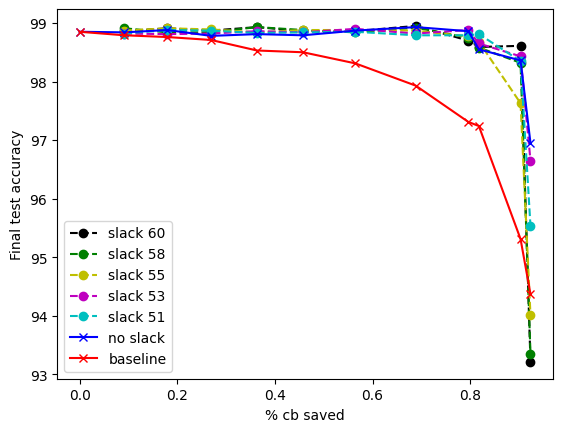

In [90]:
plt.plot(perc_cb_saved[1:],alpha_test_acc_slack[60], "k--",label="slack 60", marker="o")
plt.plot(perc_cb_saved[1:],alpha_test_acc_slack[58], "g--",label="slack 58", marker="o")
plt.plot(perc_cb_saved[1:],alpha_test_acc_slack[55], "y--",label="slack 55", marker="o")
plt.plot(perc_cb_saved[1:],alpha_test_acc_slack[53], "m--",label="slack 53", marker="o")
plt.plot(perc_cb_saved[1:],alpha_test_acc_slack[51], "c--",label="slack 51", marker="o")
plt.plot(perc_cb_saved,alpha_test_acc_50, "b-",label="no slack", marker="x")
plt.plot(perc_cb_saved,base_test_acc, "r-",label="baseline", marker="x")
plt.xlabel("% cb saved")
plt.ylabel("Final test accuracy")
plt.legend()

ValueError: min() iterable argument is empty

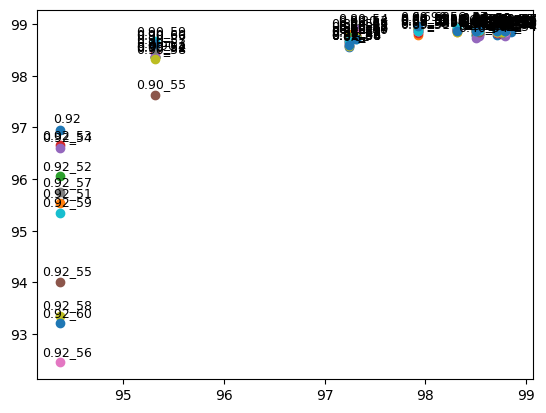

In [92]:
plt.figure()
plt.scatter(
    base_test_acc,
    alpha_test_acc_50,
    marker='o', 
)

for i in range(len(base_test_acc)):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],alpha_test_acc_50[i]), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )
    

for sl in range(51, 61):
    plt.scatter(
    base_test_acc[1:],
    alpha_test_acc_slack[sl],
    marker='o', 
    )
    for i in range(len(base_test_acc[1:])):
        plt.annotate(
            f'{perc_cb_saved[i+1]:.2f}_{sl}', # ignoring the first one since it corresponds to the baseline
            (base_test_acc[i+1],alpha_test_acc_slack[sl][i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
        


x_min = min(min(base_test_acc), min(alpha_test_acc_50),min(min(k) for k in alpha_test_acc_slack.values()))


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.legend()
plt.show()

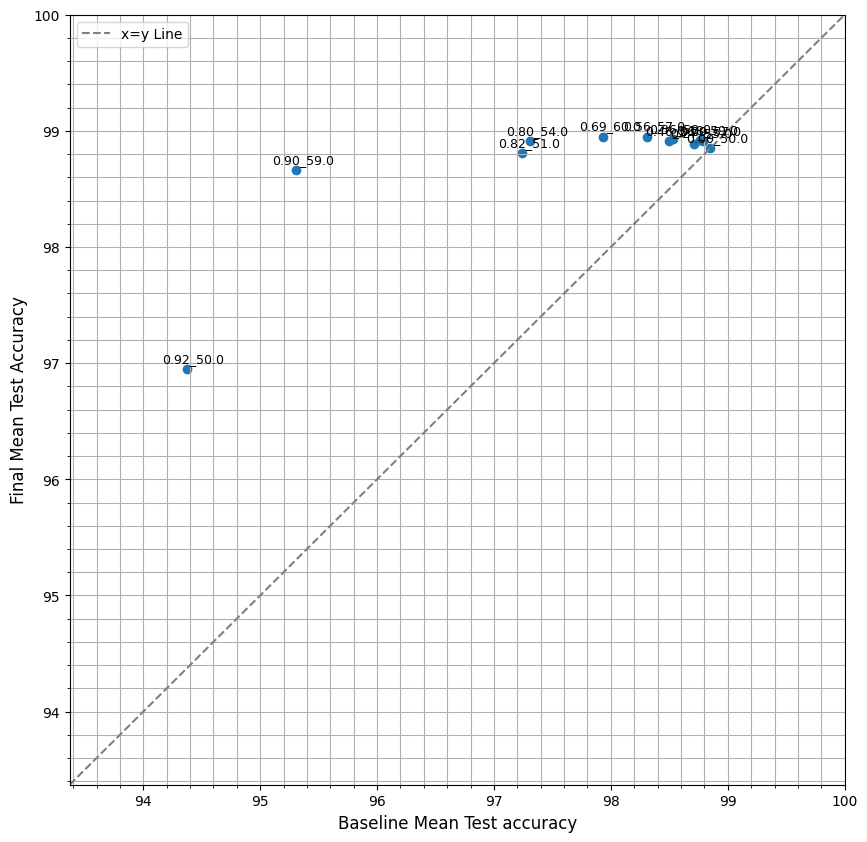

In [ ]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]

plt.figure(figsize=(10, 10))
plt.scatter(
    base_test_acc,
    _tmp['final_mean_acc'].values*100,
    marker='o', 
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}_{val[1]}', 
        (base_test_acc[i],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )
    

       
x_min = min(min(base_test_acc), min(_tmp['final_mean_acc'].values*100)) - 1 


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.legend()
plt.savefig("../../50_0.5_3ft_slack.png")
plt.show()

In [93]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-3ft alphaF50-2cb-3ft alphaF50-3cb-3ft alphaF50-4cb-3ft alphaF50-5cb-3ft alphaF50-6cb-3ft alphaF50-7cb-3ft alphaF50-8cb-3ft alphaF50-9cb-3ft alphaF50-10cb-3ft alphaF50-11cb-3ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

alphaF50-0.0cb-3ft
alphaF50-1cb-3ft
alphaF50-2cb-3ft
alphaF50-3cb-3ft
alphaF50-4cb-3ft
alphaF50-5cb-3ft
alphaF50-6cb-3ft
alphaF50-7cb-3ft
alphaF50-8cb-3ft
alphaF50-9cb-3ft
alphaF50-10cb-3ft
alphaF50-11cb-3ft


In [94]:
alpha_test_acc = results_df['final_test_accuracy']
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,9,5,4]) *100

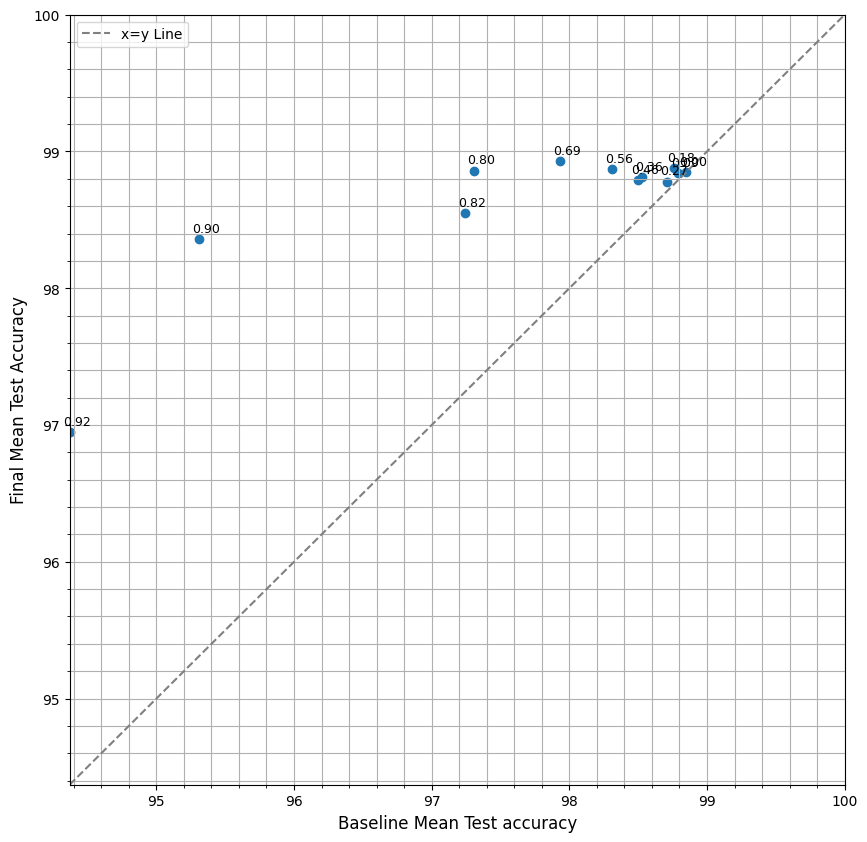

In [95]:
plt.figure(figsize=(10,10))
plt.scatter(
    base_test_acc,
    alpha_test_acc,
    marker='o', 
)

for i in range(len(base_test_acc)):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],alpha_test_acc[i]), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )

x_min = min(min(base_test_acc), min(alpha_test_acc))


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity {data_type}; fine-tuning: 1; # rounds= 5")
plt.legend()
plt.savefig("../../50_0.5_3ft.png")
plt.show()

### Fine tuning step = 1

In [72]:
# For 3 steps of fine tuning
carbon_budget_considered = GHG_matrix.sum().cumsum().to_numpy().take([44,39,34,29,24,19,14,9,4,3,2,1])
perc_cb_saved = np.insert(1 - carbon_budget_considered/total_cb, 0,0.0)

In [79]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-1ft alphaF50-2cb-1ft alphaF50-3cb-1ft alphaF50-4cb-1ft alphaF50-5cb-1ft alphaF50-6cb-1ft alphaF50-7cb-1ft alphaF50-8cb-1ft alphaF50-9cb-1ft alphaF50-10cb-1ft alphaF50-11cb-1ft alphaF50-12cb-1ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

alphaF50-0.0cb-3ft
alphaF50-1cb-1ft
alphaF50-2cb-1ft
alphaF50-3cb-1ft
alphaF50-4cb-1ft
alphaF50-5cb-1ft
alphaF50-6cb-1ft
alphaF50-7cb-1ft
alphaF50-8cb-1ft
alphaF50-9cb-1ft
alphaF50-10cb-1ft
alphaF50-11cb-1ft
alphaF50-12cb-1ft


In [80]:
alpha_test_acc = results_df['final_test_accuracy']
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,5,4,3,2]) *100

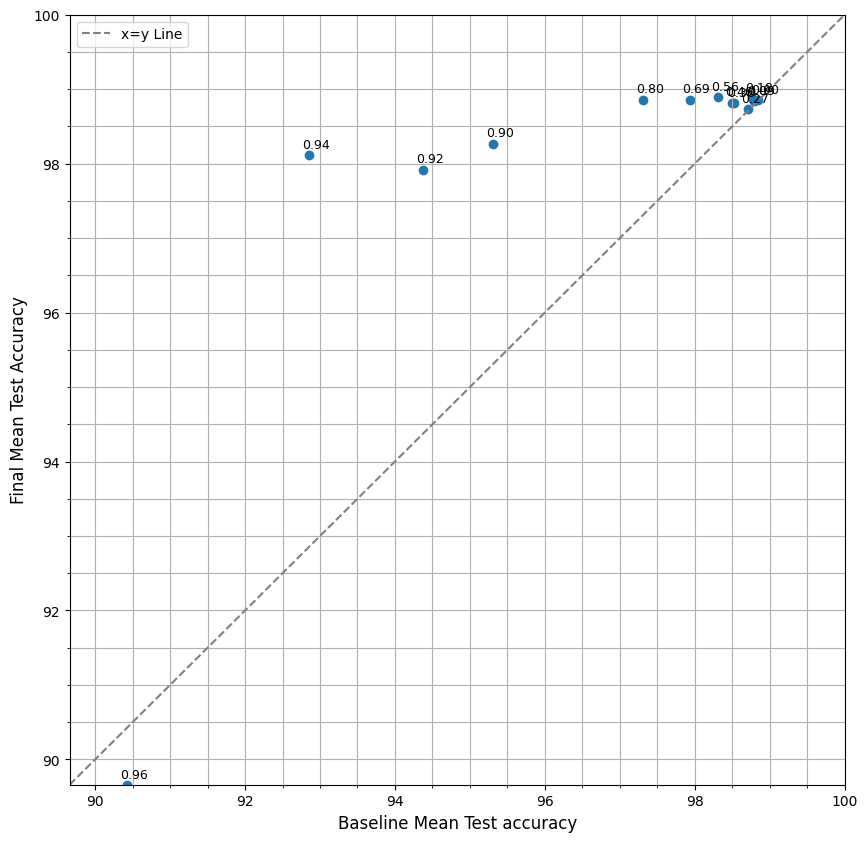

In [81]:
plt.figure(figsize=(10,10))
plt.scatter(
    base_test_acc,
    alpha_test_acc,
    marker='o', 
)

for i in range(len(base_test_acc)):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],alpha_test_acc[i]), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )

x_min = min(min(base_test_acc), min(alpha_test_acc))


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity {data_type}; fine-tuning: 1; # rounds= 5")
plt.legend()
plt.savefig("../../50_0.5_1ft.png")
plt.show()

In [71]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-1ft alphaF50-2cb-1ft alphaF50-3cb-1ft alphaF50-4cb-1ft alphaF50-5cb-1ft alphaF50-6cb-1ft alphaF50-7cb-1ft alphaF50-8cb-1ft alphaF50-9cb-1ft alphaF50-10cb-1ft alphaF50-11cb-1ft alphaF50-12cb-1ft alphaF50-200sl-10cb-1ft alphaF50-200sl-11cb-1ft alphaF50-200sl-12cb-1ft alphaF50-200sl-1cb-1ft alphaF50-200sl-2cb-1ft alphaF50-200sl-3cb-1ft alphaF50-200sl-4cb-1ft alphaF50-200sl-5cb-1ft alphaF50-200sl-6cb-1ft alphaF50-200sl-7cb-1ft alphaF50-200sl-8cb-1ft alphaF50-200sl-9cb-1ft alphaF50-180sl-10cb-1ft alphaF50-180sl-11cb-1ft alphaF50-180sl-12cb-1ft alphaF50-180sl-1cb-1ft alphaF50-180sl-2cb-1ft alphaF50-180sl-3cb-1ft alphaF50-180sl-4cb-1ft alphaF50-180sl-5cb-1ft alphaF50-180sl-6cb-1ft alphaF50-180sl-7cb-1ft alphaF50-180sl-8cb-1ft alphaF50-180sl-9cb-1ft alphaF50-160sl-10cb-1ft alphaF50-160sl-11cb-1ft alphaF50-160sl-12cb-1ft alphaF50-160sl-1cb-1ft alphaF50-160sl-2cb-1ft alphaF50-160sl-3cb-1ft alphaF50-160sl-4cb-1ft alphaF50-160sl-5cb-1ft alphaF50-160sl-6cb-1ft alphaF50-160sl-7cb-1ft alphaF50-160sl-8cb-1ft alphaF50-160sl-9cb-1ft alphaF50-140sl-10cb-1ft alphaF50-140sl-11cb-1ft alphaF50-140sl-12cb-1ft alphaF50-140sl-1cb-1ft alphaF50-140sl-2cb-1ft alphaF50-140sl-3cb-1ft alphaF50-140sl-4cb-1ft alphaF50-140sl-5cb-1ft alphaF50-140sl-6cb-1ft alphaF50-140sl-7cb-1ft alphaF50-140sl-8cb-1ft alphaF50-140sl-9cb-1ft alphaF50-120sl-10cb-1ft alphaF50-120sl-11cb-1ft alphaF50-120sl-12cb-1ft alphaF50-120sl-1cb-1ft alphaF50-120sl-2cb-1ft alphaF50-120sl-3cb-1ft alphaF50-120sl-4cb-1ft alphaF50-120sl-5cb-1ft alphaF50-120sl-6cb-1ft alphaF50-120sl-7cb-1ft alphaF50-120sl-8cb-1ft alphaF50-120sl-9cb-1ft alphaF50-100sl-10cb-1ft alphaF50-100sl-11cb-1ft alphaF50-100sl-12cb-1ft alphaF50-100sl-1cb-1ft alphaF50-100sl-2cb-1ft alphaF50-100sl-3cb-1ft alphaF50-100sl-4cb-1ft alphaF50-100sl-5cb-1ft alphaF50-100sl-6cb-1ft alphaF50-100sl-7cb-1ft alphaF50-100sl-8cb-1ft alphaF50-100sl-9cb-1ft alphaF50-90sl-10cb-1ft alphaF50-90sl-11cb-1ft alphaF50-90sl-12cb-1ft alphaF50-90sl-1cb-1ft alphaF50-90sl-2cb-1ft alphaF50-90sl-3cb-1ft alphaF50-90sl-4cb-1ft alphaF50-90sl-5cb-1ft alphaF50-90sl-6cb-1ft alphaF50-90sl-7cb-1ft alphaF50-90sl-8cb-1ft alphaF50-90sl-9cb-1ft alphaF50-80sl-10cb-1ft alphaF50-80sl-11cb-1ft alphaF50-80sl-12cb-1ft alphaF50-80sl-1cb-1ft alphaF50-80sl-2cb-1ft alphaF50-80sl-3cb-1ft alphaF50-80sl-4cb-1ft alphaF50-80sl-5cb-1ft alphaF50-80sl-6cb-1ft alphaF50-80sl-7cb-1ft alphaF50-80sl-8cb-1ft alphaF50-80sl-9cb-1ft alphaF50-70sl-10cb-1ft alphaF50-70sl-11cb-1ft alphaF50-70sl-12cb-1ft alphaF50-70sl-1cb-1ft alphaF50-70sl-2cb-1ft alphaF50-70sl-3cb-1ft alphaF50-70sl-4cb-1ft alphaF50-70sl-5cb-1ft alphaF50-70sl-6cb-1ft alphaF50-70sl-7cb-1ft alphaF50-70sl-8cb-1ft alphaF50-70sl-9cb-1ft alphaF50-60sl-10cb-1ft alphaF50-60sl-11cb-1ft alphaF50-60sl-12cb-1ft alphaF50-60sl-1cb-1ft alphaF50-60sl-2cb-1ft alphaF50-60sl-3cb-1ft alphaF50-60sl-4cb-1ft alphaF50-60sl-5cb-1ft alphaF50-60sl-6cb-1ft alphaF50-60sl-7cb-1ft alphaF50-60sl-8cb-1ft alphaF50-60sl-9cb-1ft alphaF50-59sl-10cb-1ft alphaF50-59sl-11cb-1ft alphaF50-59sl-12cb-1ft alphaF50-59sl-1cb-1ft alphaF50-59sl-2cb-1ft alphaF50-59sl-3cb-1ft alphaF50-59sl-4cb-1ft alphaF50-59sl-5cb-1ft alphaF50-59sl-6cb-1ft alphaF50-59sl-7cb-1ft alphaF50-59sl-8cb-1ft alphaF50-59sl-9cb-1ft alphaF50-58sl-10cb-1ft alphaF50-58sl-11cb-1ft alphaF50-58sl-12cb-1ft alphaF50-58sl-1cb-1ft alphaF50-58sl-2cb-1ft alphaF50-58sl-3cb-1ft alphaF50-58sl-4cb-1ft alphaF50-58sl-5cb-1ft alphaF50-58sl-6cb-1ft alphaF50-58sl-7cb-1ft alphaF50-58sl-8cb-1ft alphaF50-58sl-9cb-1ft alphaF50-57sl-10cb-1ft alphaF50-57sl-11cb-1ft alphaF50-57sl-12cb-1ft alphaF50-57sl-1cb-1ft alphaF50-57sl-2cb-1ft alphaF50-57sl-3cb-1ft alphaF50-57sl-4cb-1ft alphaF50-57sl-5cb-1ft alphaF50-57sl-6cb-1ft alphaF50-57sl-7cb-1ft alphaF50-57sl-8cb-1ft alphaF50-57sl-9cb-1ft alphaF50-56sl-10cb-1ft alphaF50-56sl-11cb-1ft alphaF50-56sl-12cb-1ft alphaF50-56sl-1cb-1ft alphaF50-56sl-2cb-1ft alphaF50-56sl-3cb-1ft alphaF50-56sl-4cb-1ft alphaF50-56sl-5cb-1ft alphaF50-56sl-6cb-1ft alphaF50-56sl-7cb-1ft alphaF50-56sl-8cb-1ft alphaF50-56sl-9cb-1ft alphaF50-55sl-10cb-1ft alphaF50-55sl-11cb-1ft alphaF50-55sl-12cb-1ft alphaF50-55sl-1cb-1ft alphaF50-55sl-2cb-1ft alphaF50-55sl-3cb-1ft alphaF50-55sl-4cb-1ft alphaF50-55sl-5cb-1ft alphaF50-55sl-6cb-1ft alphaF50-55sl-7cb-1ft alphaF50-55sl-8cb-1ft alphaF50-55sl-9cb-1ft alphaF50-54sl-10cb-1ft alphaF50-54sl-11cb-1ft alphaF50-54sl-12cb-1ft alphaF50-54sl-1cb-1ft alphaF50-54sl-2cb-1ft alphaF50-54sl-3cb-1ft alphaF50-54sl-4cb-1ft alphaF50-54sl-5cb-1ft alphaF50-54sl-6cb-1ft alphaF50-54sl-7cb-1ft alphaF50-54sl-8cb-1ft alphaF50-54sl-9cb-1ft alphaF50-53sl-10cb-1ft alphaF50-53sl-11cb-1ft alphaF50-53sl-12cb-1ft alphaF50-53sl-1cb-1ft alphaF50-53sl-2cb-1ft alphaF50-53sl-3cb-1ft alphaF50-53sl-4cb-1ft alphaF50-53sl-5cb-1ft alphaF50-53sl-6cb-1ft alphaF50-53sl-7cb-1ft alphaF50-53sl-8cb-1ft alphaF50-53sl-9cb-1ft alphaF50-52sl-10cb-1ft alphaF50-52sl-11cb-1ft alphaF50-52sl-12cb-1ft alphaF50-52sl-1cb-1ft alphaF50-52sl-2cb-1ft alphaF50-52sl-3cb-1ft alphaF50-52sl-4cb-1ft alphaF50-52sl-5cb-1ft alphaF50-52sl-6cb-1ft alphaF50-52sl-7cb-1ft alphaF50-52sl-8cb-1ft alphaF50-52sl-9cb-1ft alphaF50-51sl-10cb-1ft alphaF50-51sl-11cb-1ft alphaF50-51sl-12cb-1ft alphaF50-51sl-1cb-1ft alphaF50-51sl-2cb-1ft alphaF50-51sl-3cb-1ft alphaF50-51sl-4cb-1ft alphaF50-51sl-5cb-1ft alphaF50-51sl-6cb-1ft alphaF50-51sl-7cb-1ft alphaF50-51sl-8cb-1ft alphaF50-51sl-9cb-1ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

alphaF50-0.0cb-3ft
alphaF50-1cb-1ft
alphaF50-2cb-1ft
alphaF50-3cb-1ft
alphaF50-4cb-1ft
alphaF50-5cb-1ft


alphaF50-6cb-1ft
alphaF50-7cb-1ft
alphaF50-8cb-1ft
alphaF50-9cb-1ft
alphaF50-10cb-1ft
alphaF50-11cb-1ft
alphaF50-12cb-1ft
alphaF50-200sl-10cb-1ft
alphaF50-200sl-11cb-1ft
alphaF50-200sl-12cb-1ft
alphaF50-200sl-1cb-1ft
alphaF50-200sl-2cb-1ft
alphaF50-200sl-3cb-1ft
alphaF50-200sl-4cb-1ft
alphaF50-200sl-5cb-1ft
alphaF50-200sl-6cb-1ft
alphaF50-200sl-7cb-1ft
alphaF50-200sl-8cb-1ft
alphaF50-200sl-9cb-1ft
alphaF50-180sl-10cb-1ft
alphaF50-180sl-11cb-1ft
alphaF50-180sl-12cb-1ft
alphaF50-180sl-1cb-1ft
alphaF50-180sl-2cb-1ft
alphaF50-180sl-3cb-1ft
alphaF50-180sl-4cb-1ft
alphaF50-180sl-5cb-1ft
alphaF50-180sl-6cb-1ft
alphaF50-180sl-7cb-1ft
alphaF50-180sl-8cb-1ft
alphaF50-180sl-9cb-1ft
alphaF50-160sl-10cb-1ft
alphaF50-160sl-11cb-1ft
alphaF50-160sl-12cb-1ft
alphaF50-160sl-1cb-1ft
alphaF50-160sl-2cb-1ft
alphaF50-160sl-3cb-1ft
alphaF50-160sl-4cb-1ft
alphaF50-160sl-5cb-1ft
alphaF50-160sl-6cb-1ft
alphaF50-160sl-7cb-1ft
alphaF50-160sl-8cb-1ft
alphaF50-160sl-9cb-1ft
alphaF50-140sl-10cb-1ft
alphaF50-140sl-11

KeyError: 'Key Test/Metric was not found in Reservoir'

In [76]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    batch_sizes=["128"],
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-1ft alphaF50-2cb-1ft alphaF50-3cb-1ft alphaF50-4cb-1ft alphaF50-5cb-1ft alphaF50-6cb-1ft alphaF50-7cb-1ft alphaF50-8cb-1ft alphaF50-9cb-1ft alphaF50-10cb-1ft alphaF50-11cb-1ft alphaF50-12cb-1ft alphaF50-200sl-10cb-1ft alphaF50-200sl-11cb-1ft alphaF50-200sl-12cb-1ft alphaF50-200sl-1cb-1ft alphaF50-200sl-2cb-1ft alphaF50-200sl-3cb-1ft alphaF50-200sl-4cb-1ft alphaF50-200sl-5cb-1ft alphaF50-200sl-6cb-1ft alphaF50-200sl-7cb-1ft alphaF50-200sl-8cb-1ft alphaF50-200sl-9cb-1ft alphaF50-180sl-10cb-1ft alphaF50-180sl-11cb-1ft alphaF50-180sl-12cb-1ft alphaF50-180sl-1cb-1ft alphaF50-180sl-2cb-1ft alphaF50-180sl-3cb-1ft alphaF50-180sl-4cb-1ft alphaF50-180sl-5cb-1ft alphaF50-180sl-6cb-1ft alphaF50-180sl-7cb-1ft alphaF50-180sl-8cb-1ft alphaF50-180sl-9cb-1ft alphaF50-160sl-10cb-1ft alphaF50-160sl-11cb-1ft alphaF50-160sl-12cb-1ft alphaF50-160sl-1cb-1ft alphaF50-160sl-2cb-1ft alphaF50-160sl-3cb-1ft alphaF50-160sl-4cb-1ft alphaF50-160sl-5cb-1ft alphaF50-160sl-6cb-1ft alphaF50-160sl-7cb-1ft alphaF50-160sl-8cb-1ft alphaF50-160sl-9cb-1ft alphaF50-140sl-10cb-1ft alphaF50-140sl-11cb-1ft alphaF50-140sl-12cb-1ft alphaF50-140sl-1cb-1ft alphaF50-140sl-2cb-1ft alphaF50-140sl-3cb-1ft alphaF50-140sl-4cb-1ft alphaF50-140sl-5cb-1ft alphaF50-140sl-6cb-1ft alphaF50-140sl-7cb-1ft alphaF50-140sl-8cb-1ft alphaF50-140sl-9cb-1ft alphaF50-120sl-10cb-1ft alphaF50-120sl-11cb-1ft alphaF50-120sl-12cb-1ft alphaF50-120sl-1cb-1ft alphaF50-120sl-2cb-1ft alphaF50-120sl-3cb-1ft alphaF50-120sl-4cb-1ft alphaF50-120sl-5cb-1ft alphaF50-120sl-6cb-1ft alphaF50-120sl-7cb-1ft alphaF50-120sl-8cb-1ft alphaF50-120sl-9cb-1ft alphaF50-100sl-10cb-1ft alphaF50-100sl-11cb-1ft alphaF50-100sl-12cb-1ft alphaF50-100sl-1cb-1ft alphaF50-100sl-2cb-1ft alphaF50-100sl-3cb-1ft alphaF50-100sl-4cb-1ft alphaF50-100sl-5cb-1ft alphaF50-100sl-6cb-1ft alphaF50-100sl-7cb-1ft alphaF50-100sl-8cb-1ft alphaF50-100sl-9cb-1ft alphaF50-90sl-10cb-1ft alphaF50-90sl-11cb-1ft alphaF50-90sl-1cb-1ft alphaF50-90sl-2cb-1ft alphaF50-90sl-3cb-1ft alphaF50-90sl-4cb-1ft alphaF50-90sl-5cb-1ft alphaF50-90sl-6cb-1ft alphaF50-90sl-7cb-1ft alphaF50-90sl-8cb-1ft alphaF50-90sl-9cb-1ft alphaF50-80sl-10cb-1ft alphaF50-80sl-11cb-1ft alphaF50-80sl-12cb-1ft alphaF50-80sl-1cb-1ft alphaF50-80sl-2cb-1ft alphaF50-80sl-3cb-1ft alphaF50-80sl-4cb-1ft alphaF50-80sl-5cb-1ft alphaF50-80sl-6cb-1ft alphaF50-80sl-7cb-1ft alphaF50-80sl-8cb-1ft alphaF50-80sl-9cb-1ft alphaF50-70sl-10cb-1ft alphaF50-70sl-11cb-1ft alphaF50-70sl-12cb-1ft alphaF50-70sl-1cb-1ft alphaF50-70sl-2cb-1ft alphaF50-70sl-3cb-1ft alphaF50-70sl-4cb-1ft alphaF50-70sl-5cb-1ft alphaF50-70sl-6cb-1ft alphaF50-70sl-7cb-1ft alphaF50-70sl-8cb-1ft alphaF50-70sl-9cb-1ft alphaF50-60sl-10cb-1ft alphaF50-60sl-11cb-1ft alphaF50-60sl-12cb-1ft alphaF50-60sl-1cb-1ft alphaF50-60sl-2cb-1ft alphaF50-60sl-3cb-1ft alphaF50-60sl-4cb-1ft alphaF50-60sl-5cb-1ft alphaF50-60sl-6cb-1ft alphaF50-60sl-7cb-1ft alphaF50-60sl-8cb-1ft alphaF50-60sl-9cb-1ft alphaF50-59sl-10cb-1ft alphaF50-59sl-11cb-1ft alphaF50-59sl-12cb-1ft alphaF50-59sl-1cb-1ft alphaF50-59sl-2cb-1ft alphaF50-59sl-3cb-1ft alphaF50-59sl-4cb-1ft alphaF50-59sl-5cb-1ft alphaF50-59sl-6cb-1ft alphaF50-59sl-7cb-1ft alphaF50-59sl-8cb-1ft alphaF50-59sl-9cb-1ft alphaF50-58sl-10cb-1ft alphaF50-58sl-11cb-1ft alphaF50-58sl-12cb-1ft alphaF50-58sl-1cb-1ft alphaF50-58sl-2cb-1ft alphaF50-58sl-3cb-1ft alphaF50-58sl-4cb-1ft alphaF50-58sl-5cb-1ft alphaF50-58sl-6cb-1ft alphaF50-58sl-7cb-1ft alphaF50-58sl-8cb-1ft alphaF50-58sl-9cb-1ft alphaF50-57sl-10cb-1ft alphaF50-57sl-11cb-1ft alphaF50-57sl-12cb-1ft alphaF50-57sl-1cb-1ft alphaF50-57sl-2cb-1ft alphaF50-57sl-3cb-1ft alphaF50-57sl-4cb-1ft alphaF50-57sl-5cb-1ft alphaF50-57sl-6cb-1ft alphaF50-57sl-7cb-1ft alphaF50-57sl-8cb-1ft alphaF50-57sl-9cb-1ft alphaF50-56sl-10cb-1ft alphaF50-56sl-11cb-1ft alphaF50-56sl-12cb-1ft alphaF50-56sl-1cb-1ft alphaF50-56sl-2cb-1ft alphaF50-56sl-3cb-1ft alphaF50-56sl-4cb-1ft alphaF50-56sl-5cb-1ft alphaF50-56sl-6cb-1ft alphaF50-56sl-7cb-1ft alphaF50-56sl-8cb-1ft alphaF50-56sl-9cb-1ft alphaF50-55sl-10cb-1ft alphaF50-55sl-11cb-1ft alphaF50-55sl-12cb-1ft alphaF50-55sl-1cb-1ft alphaF50-55sl-2cb-1ft alphaF50-55sl-3cb-1ft alphaF50-55sl-4cb-1ft alphaF50-55sl-5cb-1ft alphaF50-55sl-6cb-1ft alphaF50-55sl-7cb-1ft alphaF50-55sl-8cb-1ft alphaF50-55sl-9cb-1ft alphaF50-54sl-10cb-1ft alphaF50-54sl-11cb-1ft alphaF50-54sl-12cb-1ft alphaF50-54sl-1cb-1ft alphaF50-54sl-2cb-1ft alphaF50-54sl-3cb-1ft alphaF50-54sl-4cb-1ft alphaF50-54sl-5cb-1ft alphaF50-54sl-6cb-1ft alphaF50-54sl-7cb-1ft alphaF50-54sl-8cb-1ft alphaF50-54sl-9cb-1ft alphaF50-53sl-10cb-1ft alphaF50-53sl-11cb-1ft alphaF50-53sl-12cb-1ft alphaF50-53sl-1cb-1ft alphaF50-53sl-2cb-1ft alphaF50-53sl-3cb-1ft alphaF50-53sl-4cb-1ft alphaF50-53sl-5cb-1ft alphaF50-53sl-6cb-1ft alphaF50-53sl-7cb-1ft alphaF50-53sl-8cb-1ft alphaF50-53sl-9cb-1ft alphaF50-52sl-10cb-1ft alphaF50-52sl-11cb-1ft alphaF50-52sl-12cb-1ft alphaF50-52sl-1cb-1ft alphaF50-52sl-2cb-1ft alphaF50-52sl-3cb-1ft alphaF50-52sl-4cb-1ft alphaF50-52sl-5cb-1ft alphaF50-52sl-6cb-1ft alphaF50-52sl-7cb-1ft alphaF50-52sl-8cb-1ft alphaF50-52sl-9cb-1ft alphaF50-51sl-10cb-1ft alphaF50-51sl-11cb-1ft alphaF50-51sl-12cb-1ft alphaF50-51sl-1cb-1ft alphaF50-51sl-2cb-1ft alphaF50-51sl-3cb-1ft alphaF50-51sl-4cb-1ft alphaF50-51sl-5cb-1ft alphaF50-51sl-6cb-1ft alphaF50-51sl-7cb-1ft alphaF50-51sl-8cb-1ft alphaF50-51sl-9cb-1ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

alphaF50-0.0cb-3ft
alphaF50-1cb-1ft
alphaF50-2cb-1ft
alphaF50-3cb-1ft
alphaF50-4cb-1ft
alphaF50-5cb-1ft
alphaF50-6cb-1ft
alphaF50-7cb-1ft
alphaF50-8cb-1ft
alphaF50-9cb-1ft
alphaF50-10cb-1ft
alphaF50-11cb-1ft
alphaF50-12cb-1ft
alphaF50-200sl-10cb-1ft
alphaF50-200sl-11cb-1ft
alphaF50-200sl-12cb-1ft
alphaF50-200sl-1cb-1ft
alphaF50-200sl-2cb-1ft
alphaF50-200sl-3cb-1ft
alphaF50-200sl-4cb-1ft
alphaF50-200sl-5cb-1ft
alphaF50-200sl-6cb-1ft
alphaF50-200sl-7cb-1ft
alphaF50-200sl-8cb-1ft
alphaF50-200sl-9cb-1ft
alphaF50-180sl-10cb-1ft
alphaF50-180sl-11cb-1ft
alphaF50-180sl-12cb-1ft
alphaF50-180sl-1cb-1ft
alphaF50-180sl-2cb-1ft
alphaF50-180sl-3cb-1ft
alphaF50-180sl-4cb-1ft
alphaF50-180sl-5cb-1ft
alphaF50-180sl-6cb-1ft
alphaF50-180sl-7cb-1ft
alphaF50-180sl-8cb-1ft
alphaF50-180sl-9cb-1ft
alphaF50-160sl-10cb-1ft
alphaF50-160sl-11cb-1ft
alphaF50-160sl-12cb-1ft
alphaF50-160sl-1cb-1ft
alphaF50-160sl-2cb-1ft
alphaF50-160sl-3cb-1ft
alphaF50-160sl-4cb-1ft
alphaF50-160sl-5cb-1ft
alphaF50-160sl-6cb-1ft
alphaF

In [77]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(50).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)

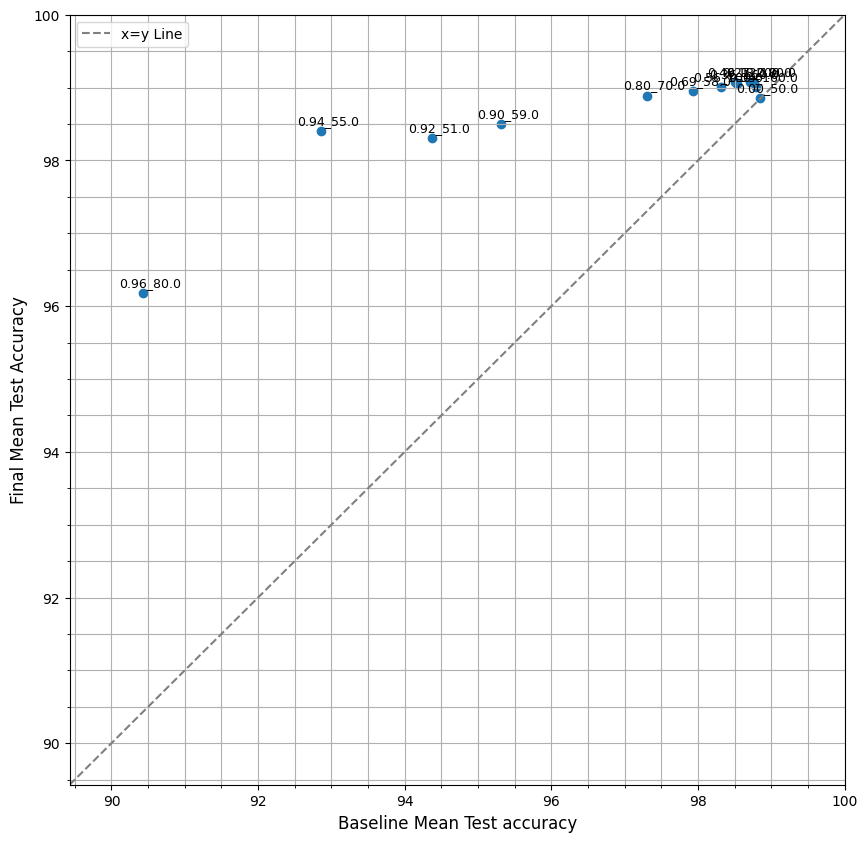

In [78]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(10,10))
plt.scatter(
    base_test_acc,
    _tmp['final_mean_acc'].values*100,
    marker='o', 
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}_{val[1]}', 
        (base_test_acc[i],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )
    

       


x_min = min(min(base_test_acc), min(_tmp['final_mean_acc'].values*100))


plt.plot([x_min-1, 100.0], [x_min-1, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 100.0)
plt.ylim(x_min-1, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.legend()
plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()

In [34]:
alpha_test_acc_50 = fed_avg.loc[fed_avg['slack_time']==50].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100
alpha_test_acc_slack = {
    51: fed_avg.loc[fed_avg['slack_time']==51].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    52: fed_avg.loc[fed_avg['slack_time']==52].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    53: fed_avg.loc[fed_avg['slack_time']==53].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    54: fed_avg.loc[fed_avg['slack_time']==54].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    55: fed_avg.loc[fed_avg['slack_time']==55].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    56: fed_avg.loc[fed_avg['slack_time']==56].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    57: fed_avg.loc[fed_avg['slack_time']==57].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    58: fed_avg.loc[fed_avg['slack_time']==58].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    59: fed_avg.loc[fed_avg['slack_time']==59].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    60: fed_avg.loc[fed_avg['slack_time']==60].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    70: fed_avg.loc[fed_avg['slack_time']==70].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    80: fed_avg.loc[fed_avg['slack_time']==80].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    90: fed_avg.loc[fed_avg['slack_time']==90].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    100: fed_avg.loc[fed_avg['slack_time']==100].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    120: fed_avg.loc[fed_avg['slack_time']==120].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    140: fed_avg.loc[fed_avg['slack_time']==140].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    160: fed_avg.loc[fed_avg['slack_time']==160].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    180: fed_avg.loc[fed_avg['slack_time']==180].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    200: fed_avg.loc[fed_avg['slack_time']==200].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100
}
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,5,4,3,2])*100

In [29]:
pd.DataFrame.from_dict(alpha_test_acc_slack).to_csv("../1ft.csv")

In [32]:
base_test_acc

array([98.8499999 , 98.79000187, 98.76000285, 98.71000051, 98.53000045,
       98.50000143, 98.3099997 , 97.93000221, 97.31000066, 95.31000257,
       94.37000155, 92.86000133, 90.42999744])

In [33]:
alpha_test_acc_50

array([98.8499999 , 98.83999825, 98.87999892, 98.72999787, 98.80999923,
       98.82000089, 98.89000058, 98.86000156, 98.86000156, 98.26999903,
       97.92000055, 98.11999798, 89.6600008 ])

In [35]:
alpha_test_acc_slack[90]

array([98.9199996 , 99.04000163, 98.97999763, 98.97000194, 99.01000261,
       98.93000126, 98.6899972 , 98.65000248, 98.29000235, 95.85000277,
       91.00000262])